In [388]:
import math
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from multiprocessing import Pool

# Введение в теорию хаоса: логистическое отображение

В этом уроке мы исследуем одну из самых удивительных математических систем -
**логистическое отображение**, простое итерационное уравнение, которое демонстрирует
невероятно сложное поведение.

Мы увидим, как простая формула может порождать:
- Стабильные состояния
- Периодические колебания
- Каскады бифуркаций
- Детерминированный хаос

Это путешествие от порядка к хаосу продемонстрирует фундаментальные принципы
нелинейной динамики и теории хаоса.

## Глава первая. История одного процесса

Начнем с простого наблюдения за поведением итерационного процесса
и постепенно будем открывать его удивительные свойства.

Мы исследуем параметризованный итерационный процесс:

In [389]:
def process(x, a):
    return a * x * (1 - x)

Смоделируем 10 шагов функции:

In [390]:
def print_process(x0, a, steps, process):
    x = x0
    for _ in range(steps):
        print(round(x, 5), end=' ➔ ')
        x = process(x=x, a=a)

In [391]:
        # time.sleep(1)

print_process(x0=0.3, a=2, steps=10, process=process)

0.3 ➔ 0.42 ➔ 0.4872 ➔ 0.49967 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 0.5 ➔ 

Как видно, значение стабилизировалось на 0.5

Построим график процесса.

In [392]:
def draw_process_chart(x0, a, steps, process, every=1, fixed_ylim=False):
    """Рисует процесс; fixed_ylim=True задаёт диапазон Y от 0 до 1."""
    x = x0
    xs = []
    for t in range(steps):
        if t%every == 0:
            xs.append(x)
        x = process(x, a)

    fig, ax = plt.subplots()
    plt.title(f'a = {round(a,5)}')

    ax.plot(xs)
    ax.grid()
    ax.set_xlabel('steps')
    ax.set_ylabel('x')
    if fixed_ylim:
        ax.set_ylim(0, 1)
    plt.show()
    plt.close()

Мы будем много раз дальше рисовать этот график, и нужно поговорить о параметрах, которые мы в него передаем. Начальное значение x на самом деле, как выяснится далее, не очень важно - можно взять любое случайное число в пределах от 0 до 1. Желательно, однако, что бы это число было одним и тем же во всех графиках. Поэтому мы сгенерируем такое число и будем его использовать

In [393]:
X0 = np.random.random()
print(X0)

0.6414702266299747


steps означает число шагов (итераций) процесса.

every - параметр, обозначающий раз в сколько лет мы отмечаем значение процесса на графике. Это пригодится позже.

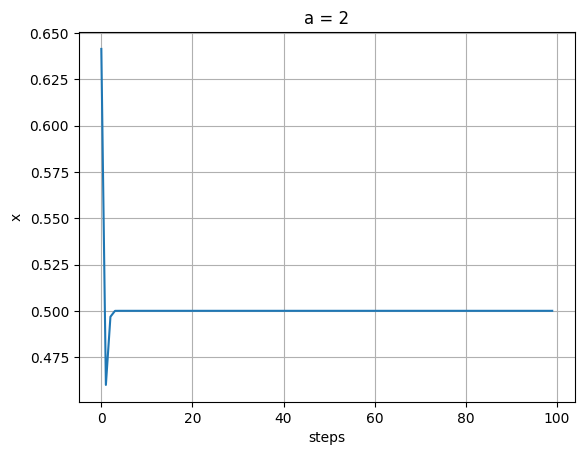

In [394]:
draw_process_chart(X0, a=2, steps=100, process=process)

Неподвижные точки процесса:

    x = 0
    x = (a-1)/a

In [395]:
def process(x, a):
    return a * x * (1 - x)

In [396]:
a_test = 1.5
print_process(x0=X0, a=a_test, steps=10, process=process)

0.64147 ➔ 0.34498 ➔ 0.33895 ➔ 0.3361 ➔ 0.3347 ➔ 0.33402 ➔ 0.33367 ➔ 0.3335 ➔ 0.33342 ➔ 0.33338 ➔ 

In [397]:
print((a_test-1)/a_test)

0.3333333333333333


Формулируем гипотезу: значение стабилизируется в неподвижной точке процесса.

Проверим её на различных значениях a. Для этого создадим демо, где график будет зависеть от a.

In [398]:
# Если ipywidgets не установлен, выполните в отдельной ячейке: %pip install ipywidgets
from ipywidgets import FloatSlider, interact

@interact(a=FloatSlider(
    value=2.0,
    min=0.0,
    max=4.00,
    step=0.01,
    description='a',
    readout_format='.2f',
    continuous_update=True,
))
def logistic_demo(a):
    print_process(x0=X0, a=a, steps=30, process=process)
    draw_process_chart(x0=X0, a=a, steps=100, process=process, fixed_ylim=True)


interactive(children=(FloatSlider(value=2.0, description='a', max=4.0, step=0.01), Output()), _dom_classes=('w…

Как можно видеть, значение и не думает стабилизироваться. Гипотеза не верна!

Проверим, что будет происходить, если мы будем увеличивать а

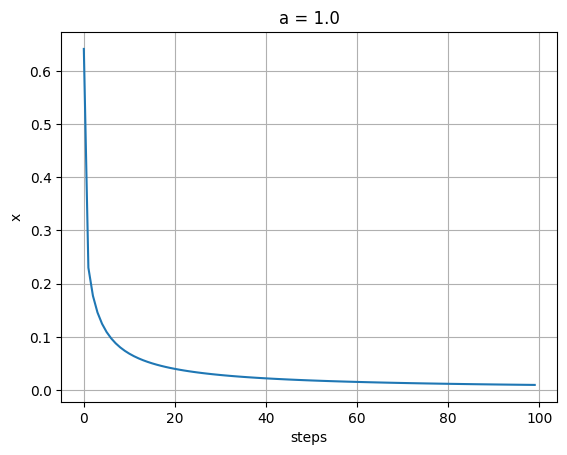

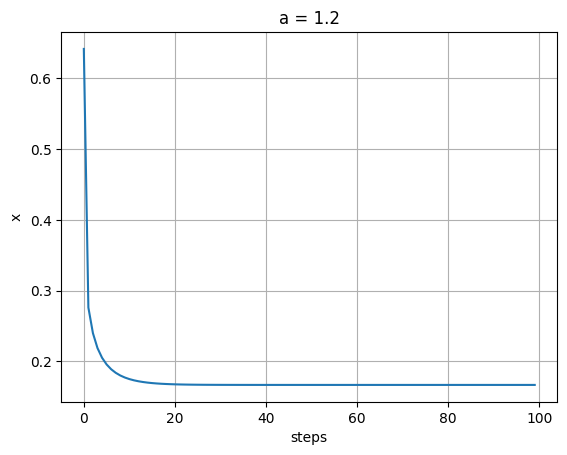

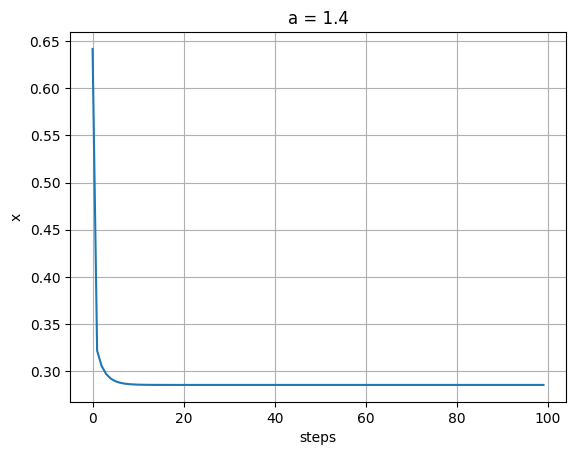

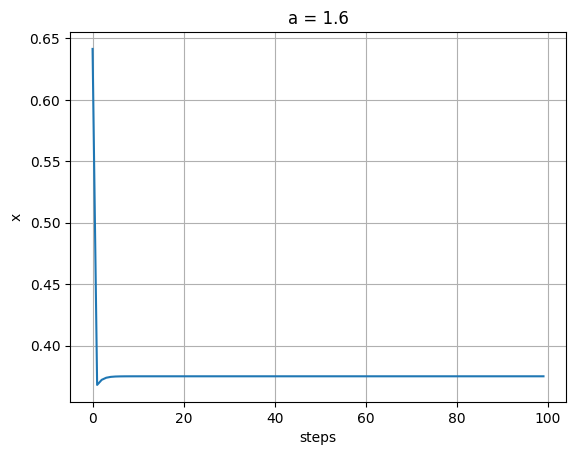

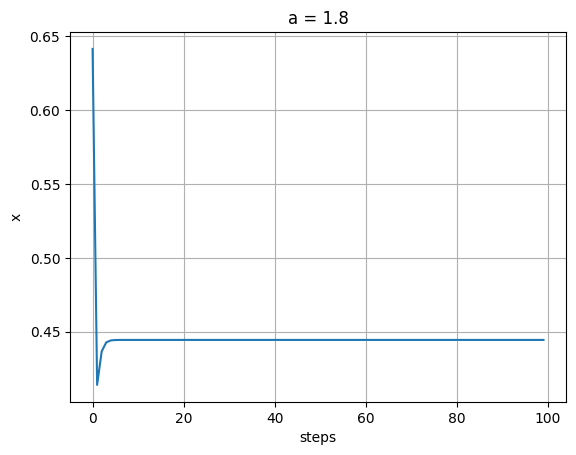

In [399]:
for a in np.arange(1, 2, 0.2):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Пока всё идет хорошо. Значение стабилизируется в неподвижной точки процесса

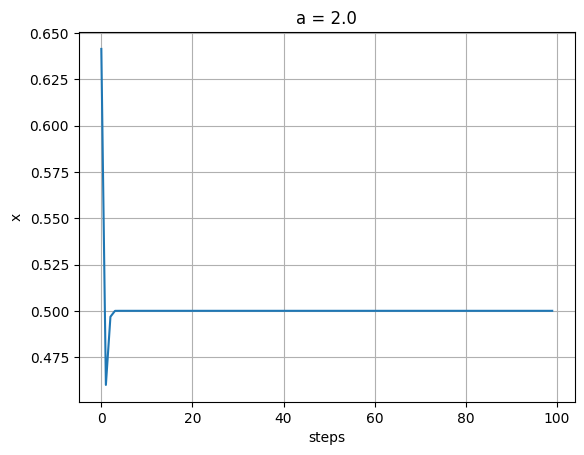

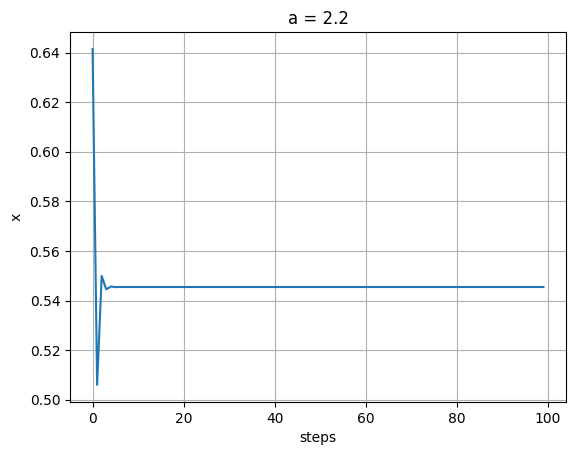

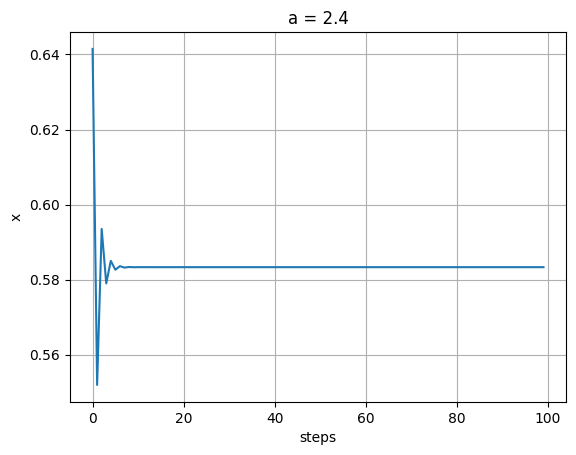

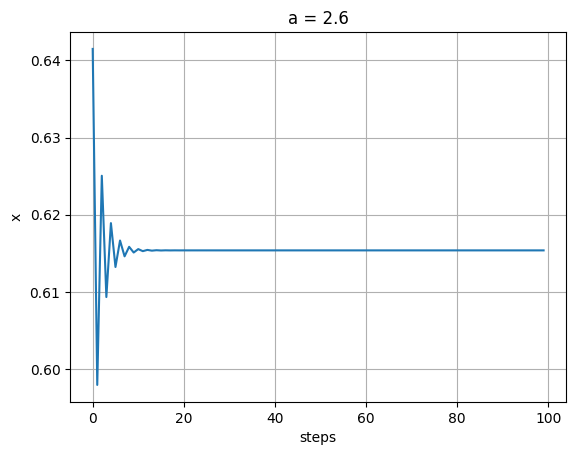

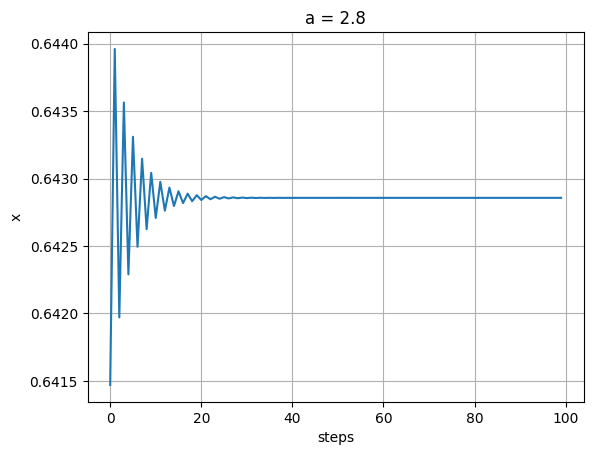

In [400]:
for a in np.arange(2, 2.9, 0.2):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Мы видим, что возникает дрожание. Значение пытается стабилизироваться

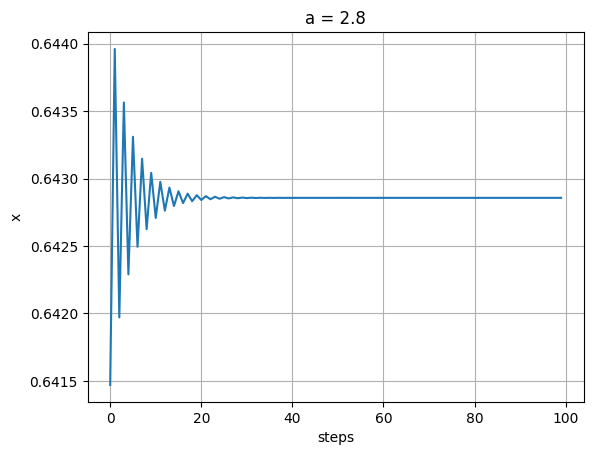

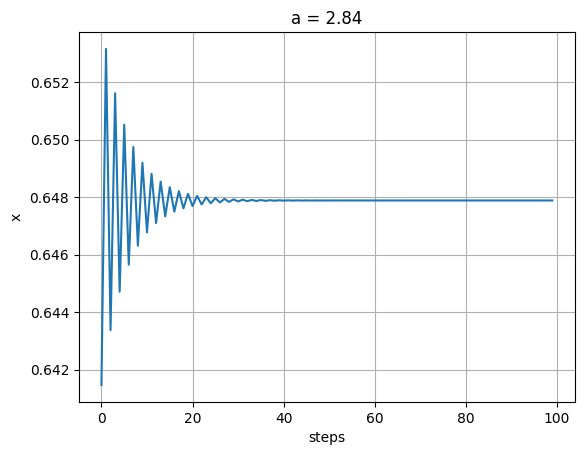

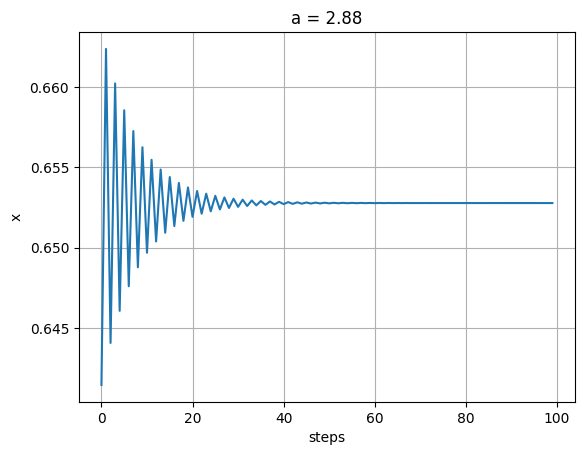

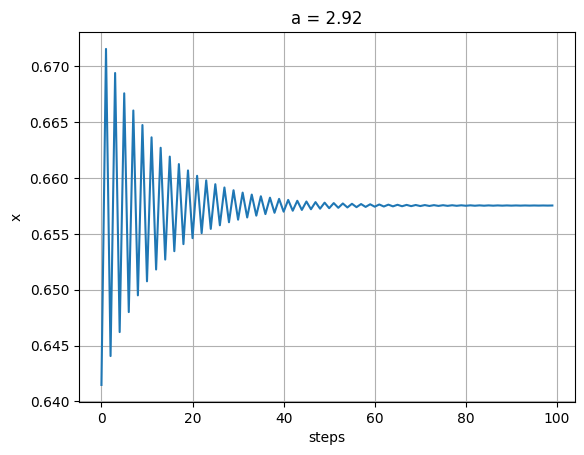

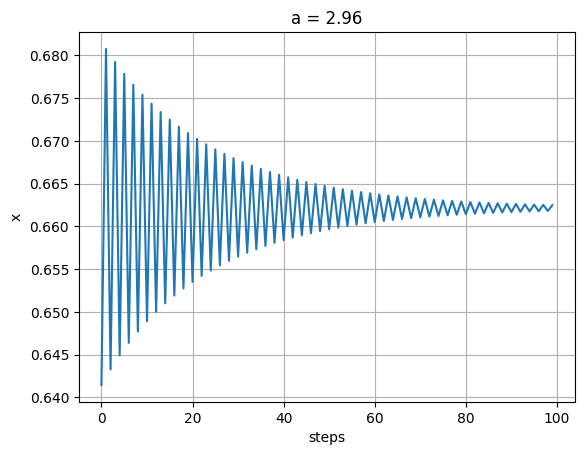

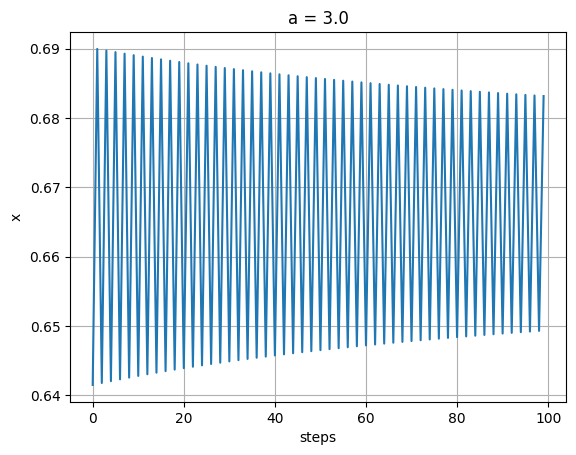

In [401]:
for a in np.arange(2.8, 3, 0.04):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Постепенно способность стабилизироваться теряется

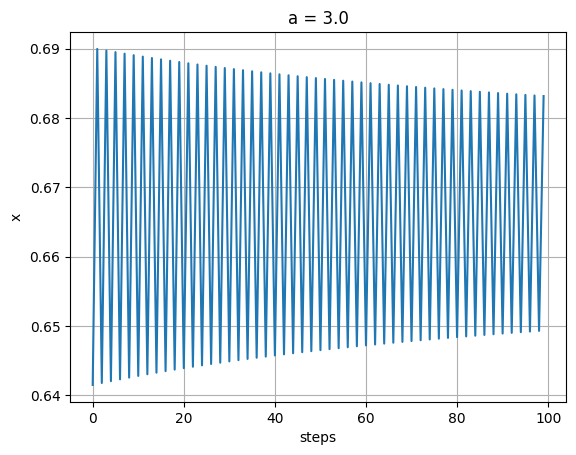

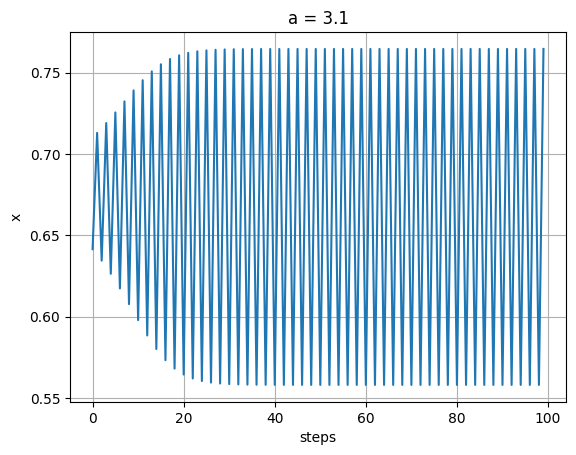

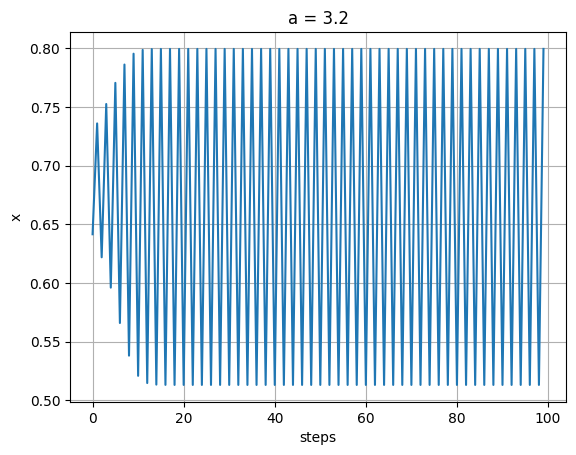

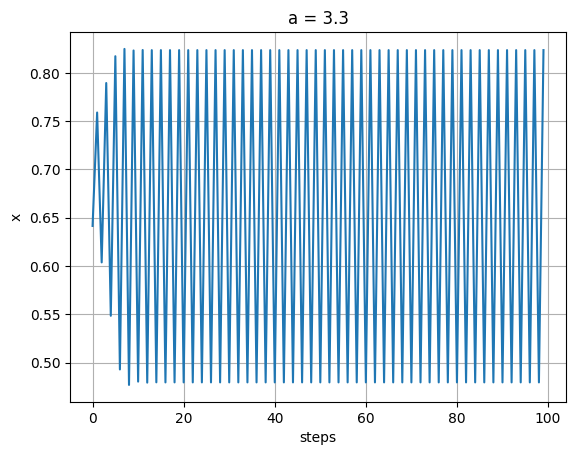

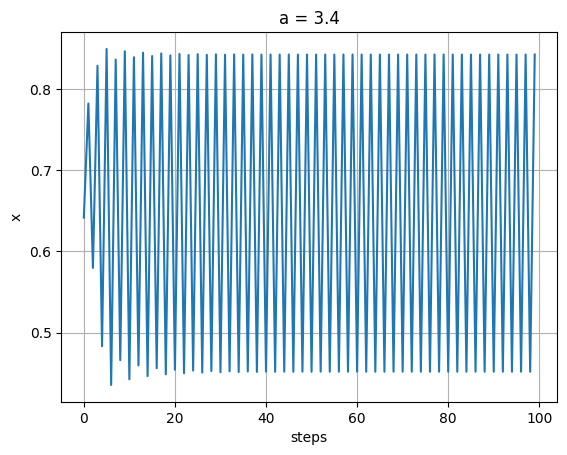

In [402]:
for a in np.arange(3, 3.5, 0.1):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Происходит странное - вместо того, что бы сойтись к определенному значению, процесс начинает "*гулять*" между двумя.

In [403]:
print_process(x0=X0, a=3.4, steps=100, process=process)

0.64147 ➔ 0.78195 ➔ 0.57971 ➔ 0.8284 ➔ 0.48333 ➔ 0.84905 ➔ 0.43575 ➔ 0.83596 ➔ 0.46624 ➔ 0.84612 ➔ 0.44267 ➔ 0.83883 ➔ 0.45967 ➔ 0.84447 ➔ 0.44656 ➔ 0.84029 ➔ 0.45629 ➔ 0.8435 ➔ 0.44882 ➔ 0.84109 ➔ 0.45443 ➔ 0.84294 ➔ 0.45014 ➔ 0.84155 ➔ 0.45338 ➔ 0.84261 ➔ 0.4509 ➔ 0.8418 ➔ 0.45278 ➔ 0.84242 ➔ 0.45135 ➔ 0.84195 ➔ 0.45243 ➔ 0.84231 ➔ 0.45161 ➔ 0.84204 ➔ 0.45223 ➔ 0.84224 ➔ 0.45176 ➔ 0.84209 ➔ 0.45212 ➔ 0.84221 ➔ 0.45184 ➔ 0.84212 ➔ 0.45205 ➔ 0.84218 ➔ 0.45189 ➔ 0.84213 ➔ 0.45202 ➔ 0.84217 ➔ 0.45192 ➔ 0.84214 ➔ 0.45199 ➔ 0.84216 ➔ 0.45194 ➔ 0.84215 ➔ 0.45198 ➔ 0.84216 ➔ 0.45195 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45197 ➔ 0.84216 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 0.45196 ➔ 0.84215 ➔ 

Участок от 3.4 до 4 мы будем исследовать с меньшим шагом между a

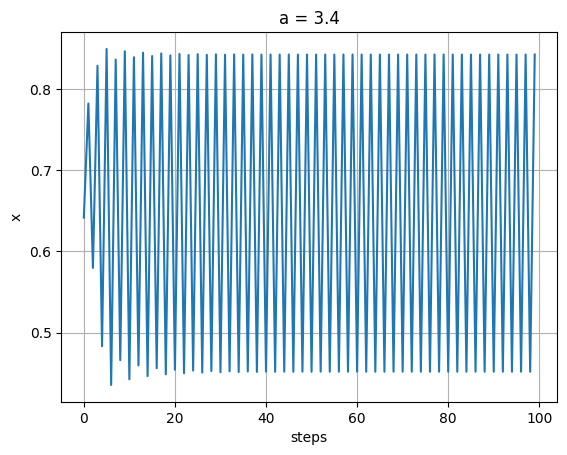

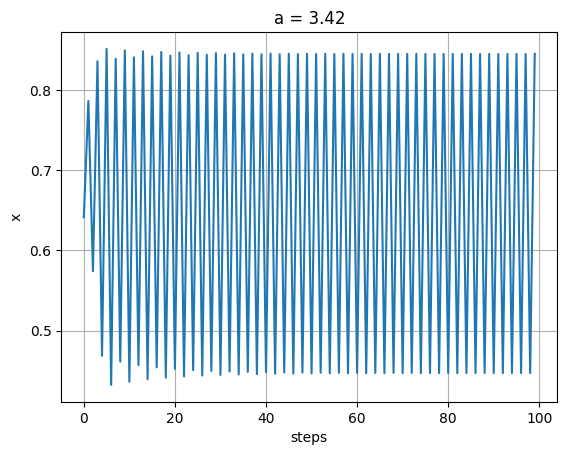

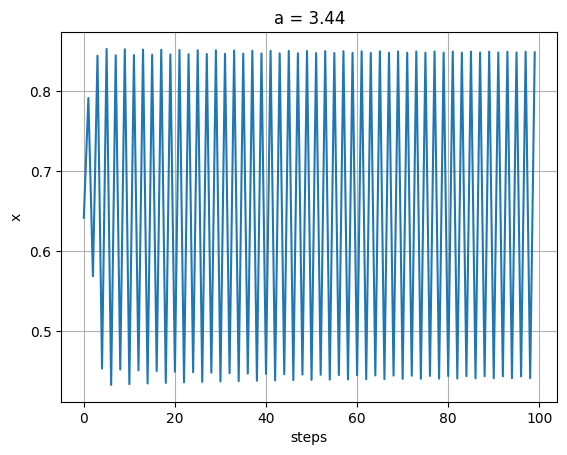

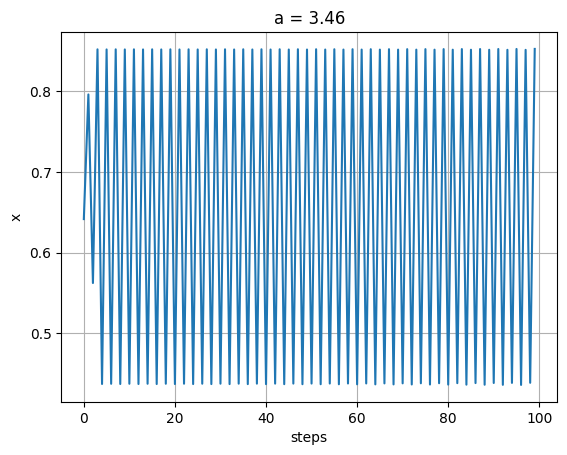

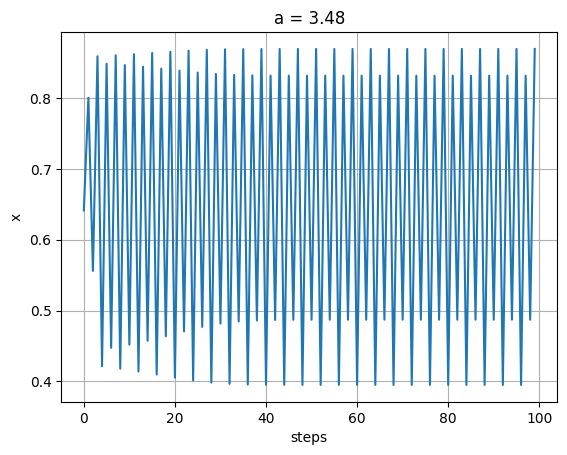

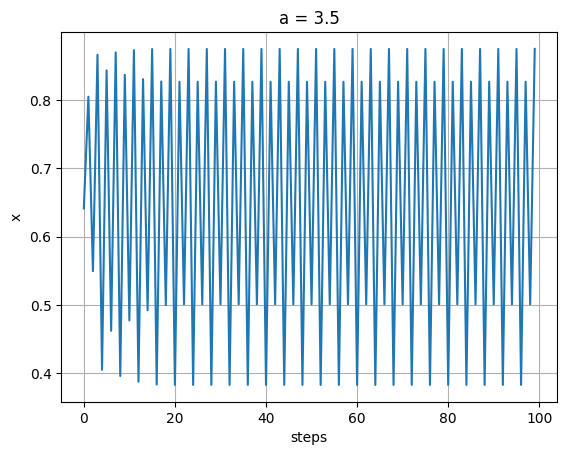

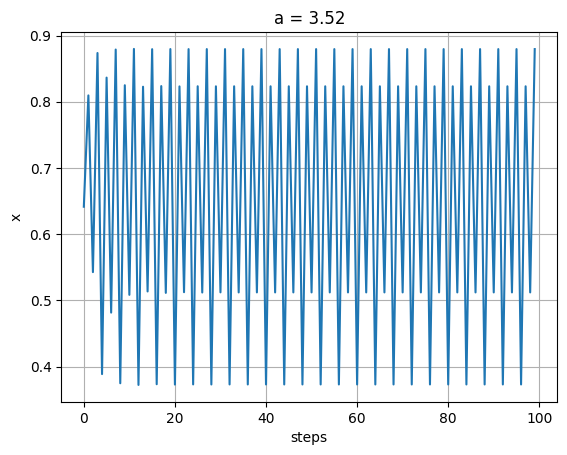

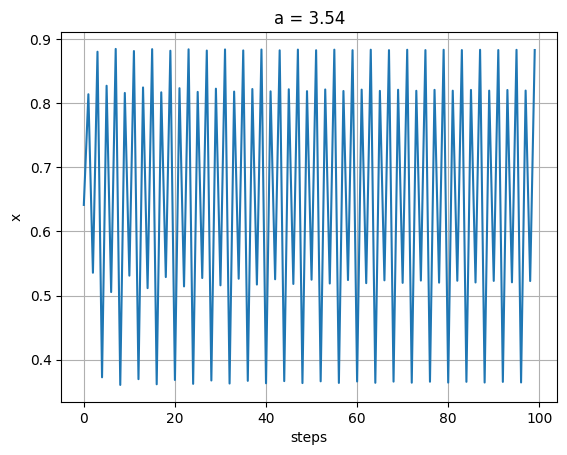

In [404]:
for a in np.arange(3.4, 3.54, 0.02):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

Наш процесс опять раздвоило. Теперь он прыгает между 4 значениями.

Для дальнейшего исследования, мы будем моделировать *в два раза больше* лет, но рисовать на графике *каждый второй год*

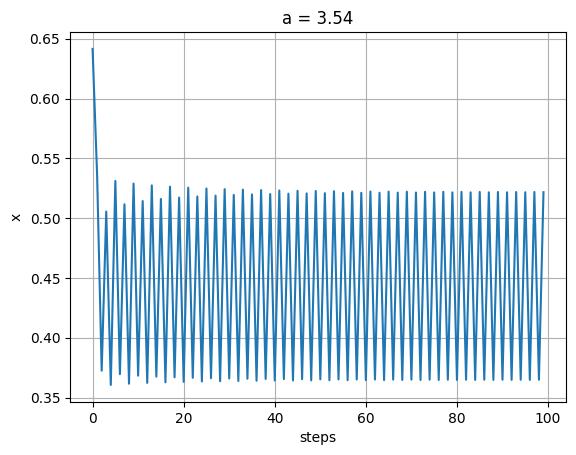

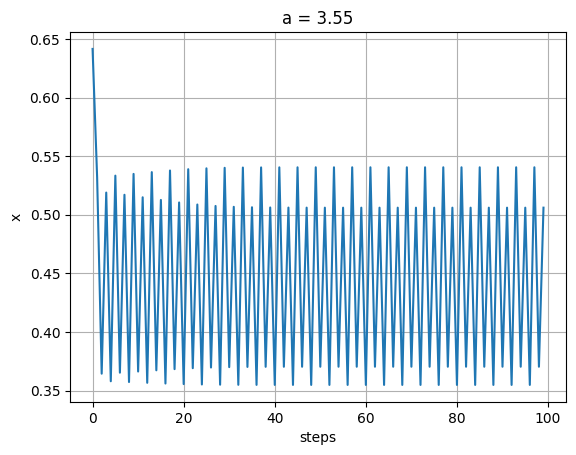

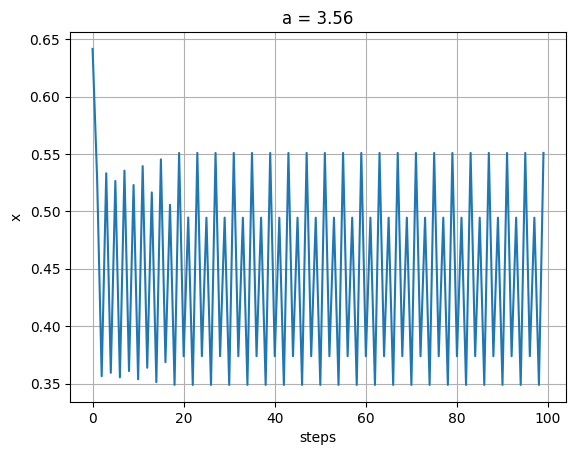

In [405]:
for a in np.arange(3.54, 3.56, 0.01):
    draw_process_chart(x0=X0, a=a, steps=200, process=process, every=2)

Как видно, значение *опять раздвоило*. Мы рисовали каждый второй год, а истинная картина при a=3.56 выглядит так:

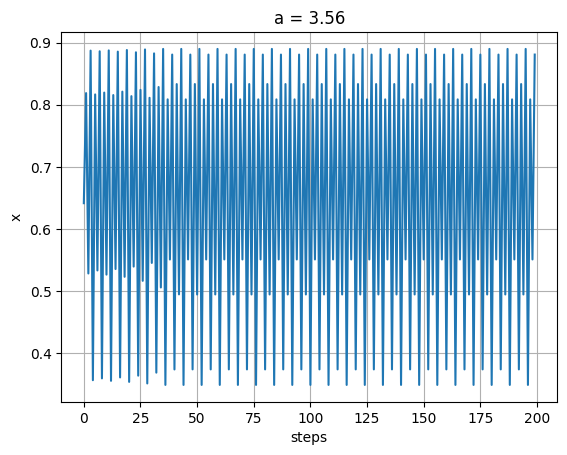

In [406]:
draw_process_chart(x0=X0, a=3.56, steps=200, process=process)

Будем рисовать каждый восьмой год:

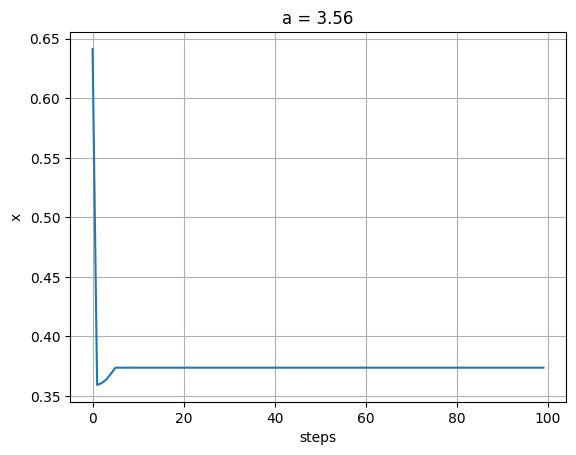

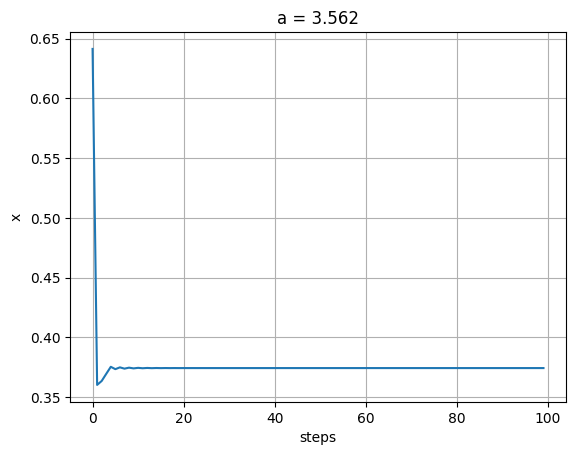

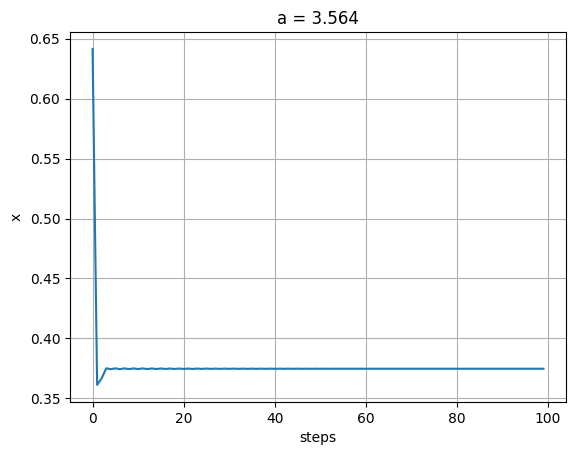

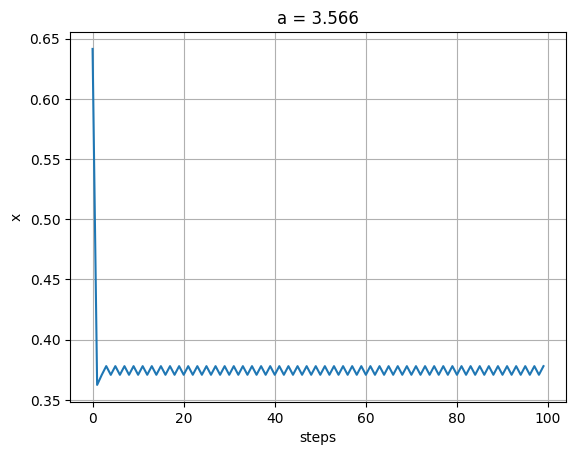

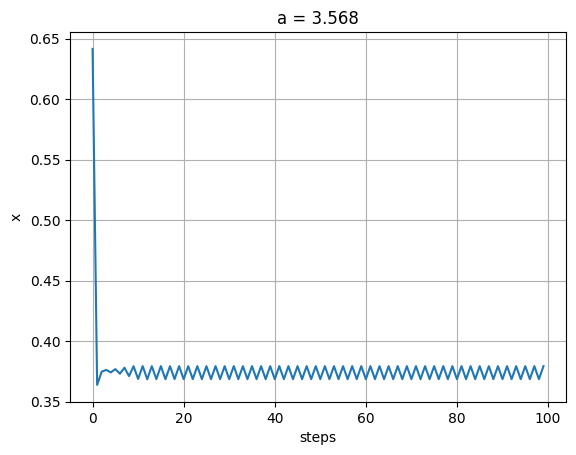

In [407]:
for a in np.arange(3.56, 3.57, 0.002):
    draw_process_chart(x0=X0, a=a, steps=800, process=process, every=8)

Можно видеть, как периоды удваивались ещё раз, затем ещё раз.

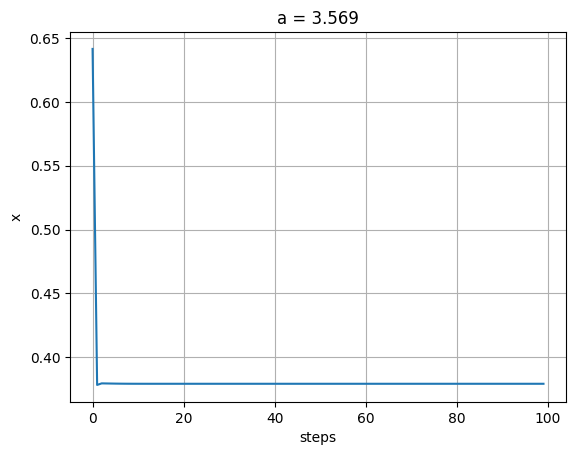

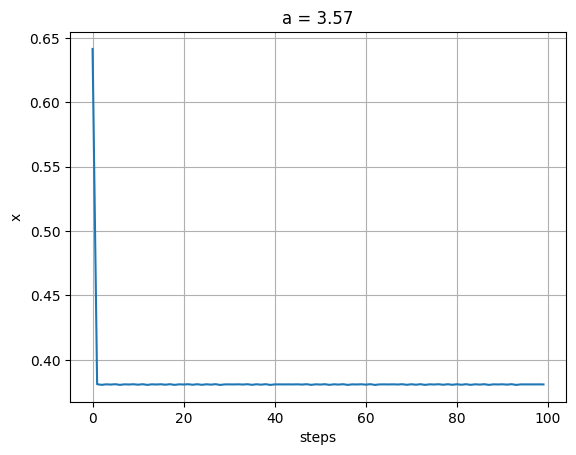

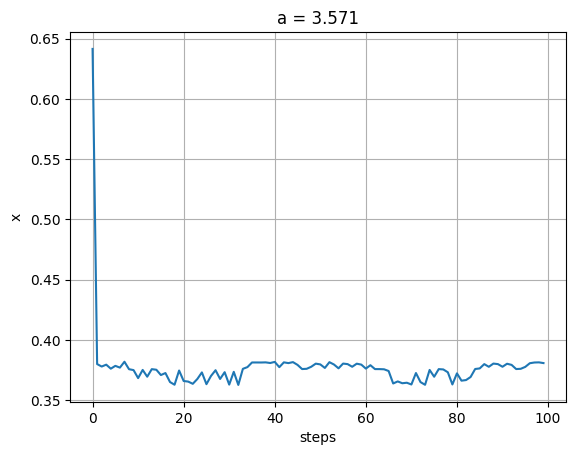

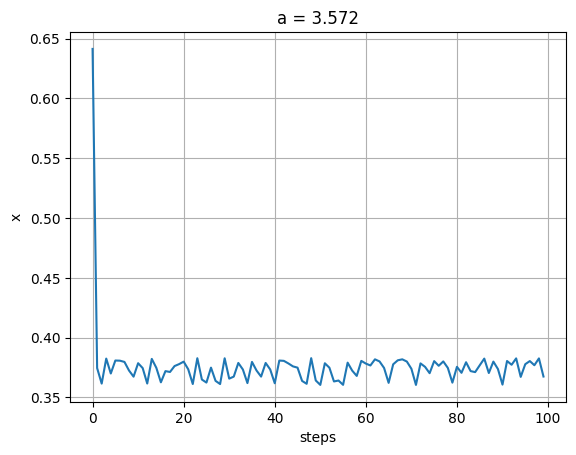

In [408]:
for a in np.arange(3.569, 3.572, 0.001):
    draw_process_chart(x0=X0, a=a, steps=3200, process=process, every=32)

Видно, что в какой-то момент последовательность начинает разбалтывать, и это уже сложно обьяснить удвоением периода. Рассмотрим каждый 64 элемент с мелким шагом до 3.59:

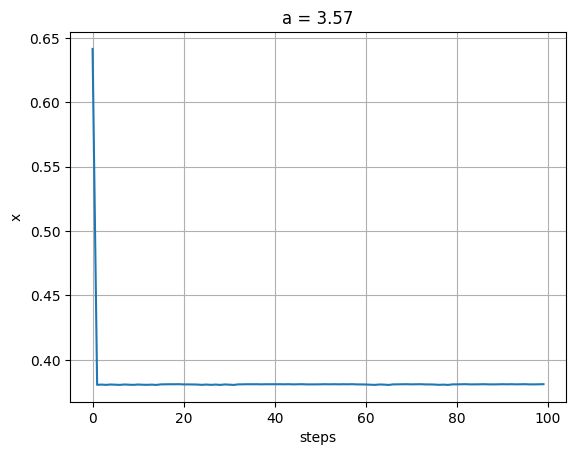

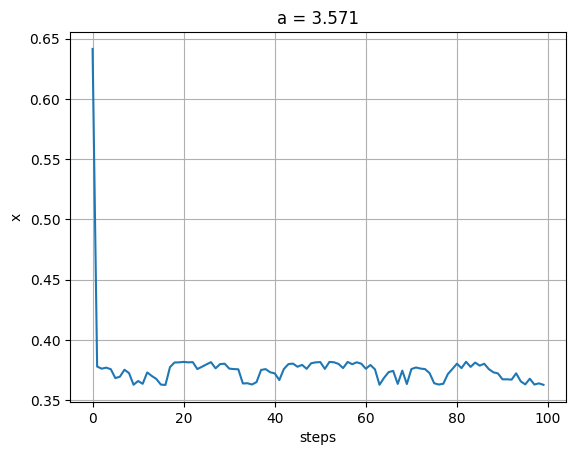

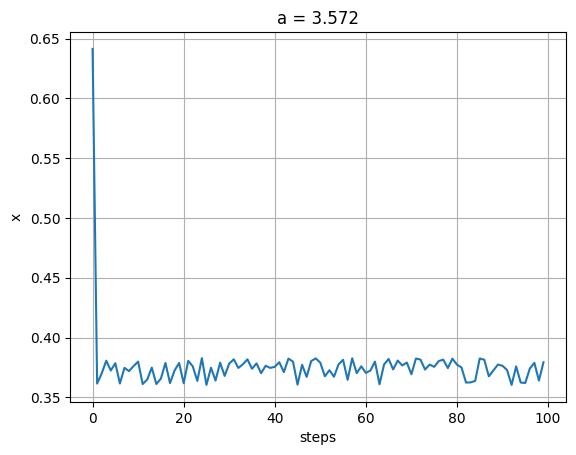

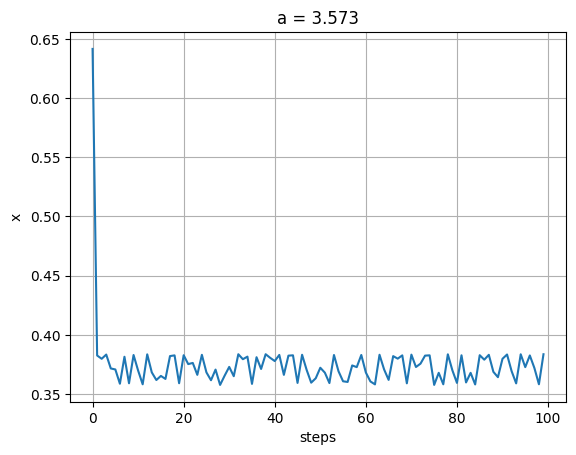

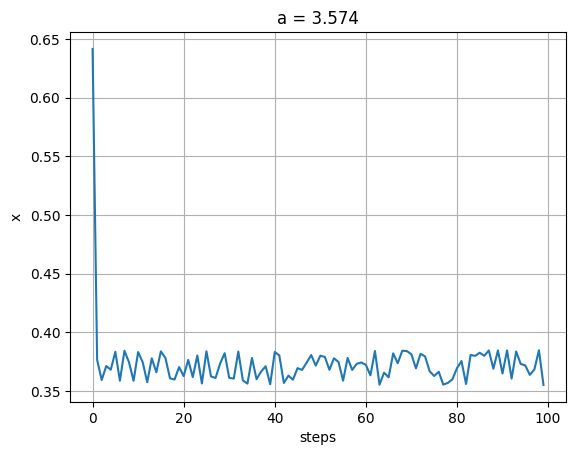

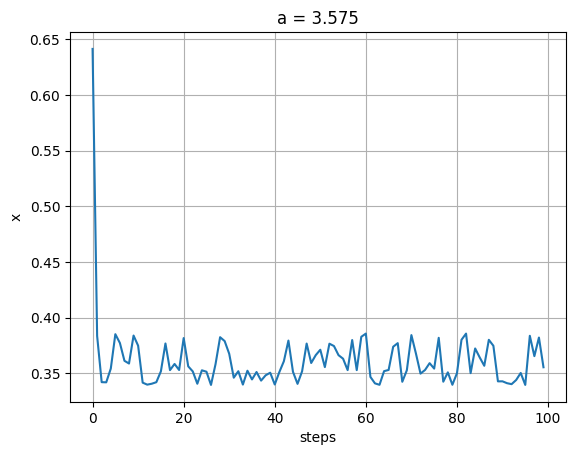

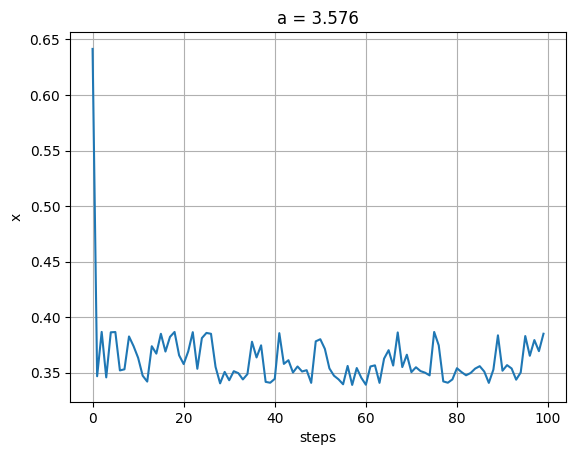

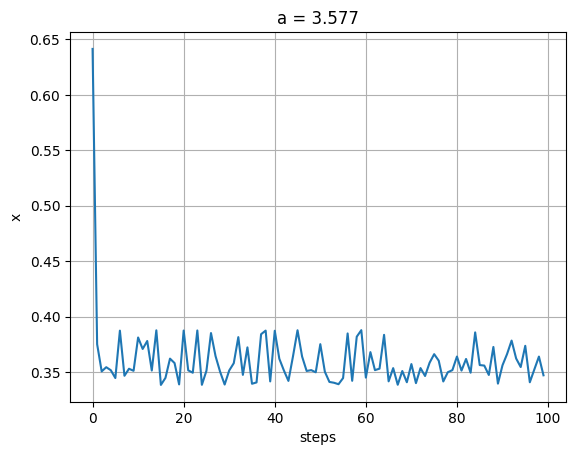

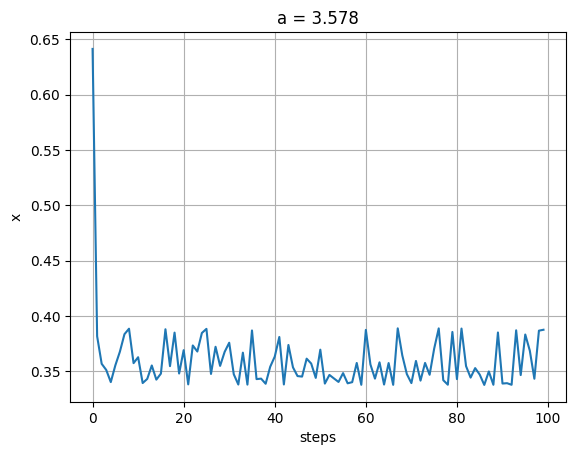

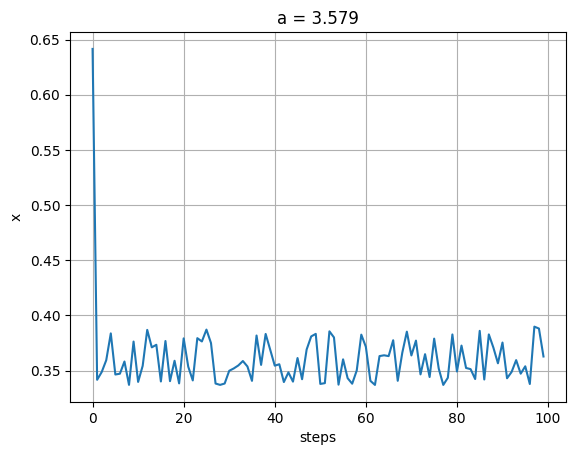

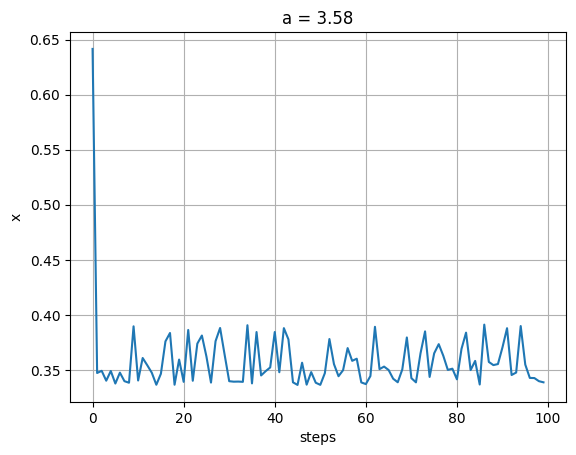

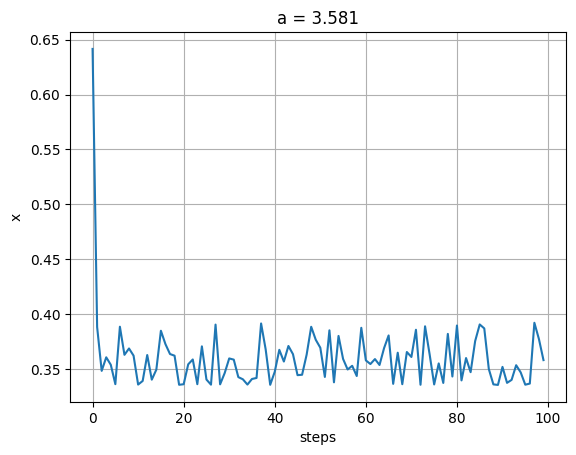

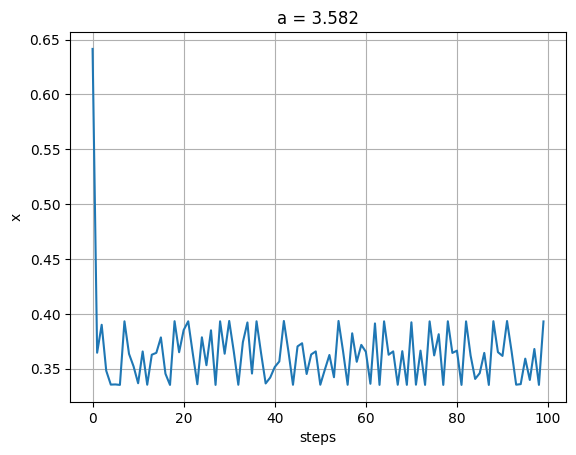

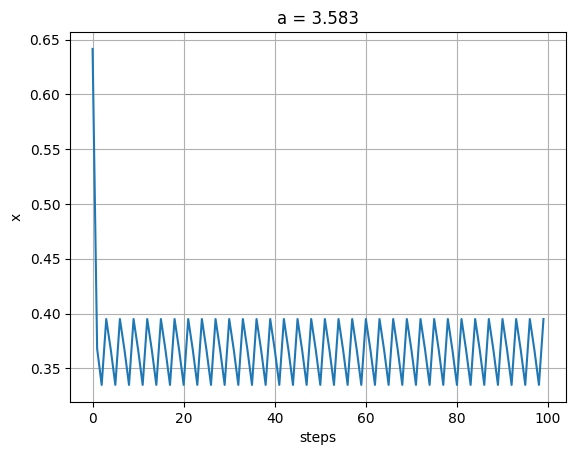

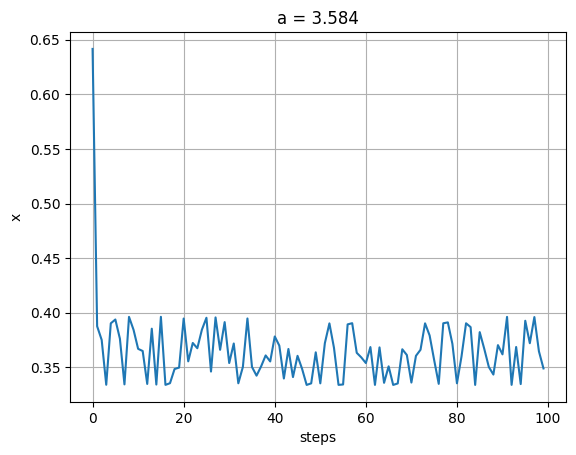

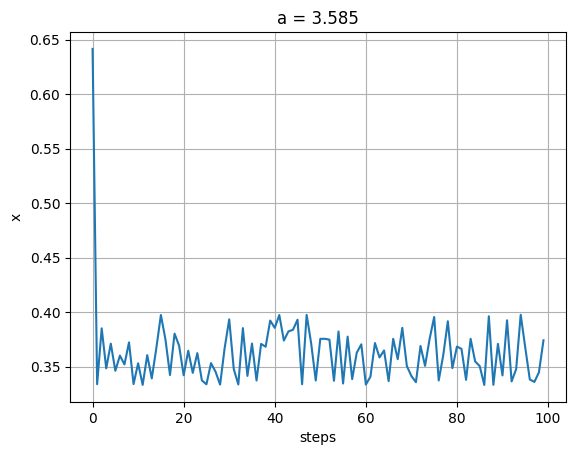

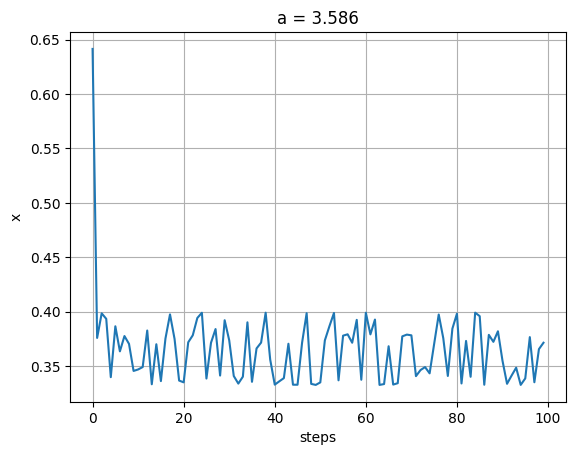

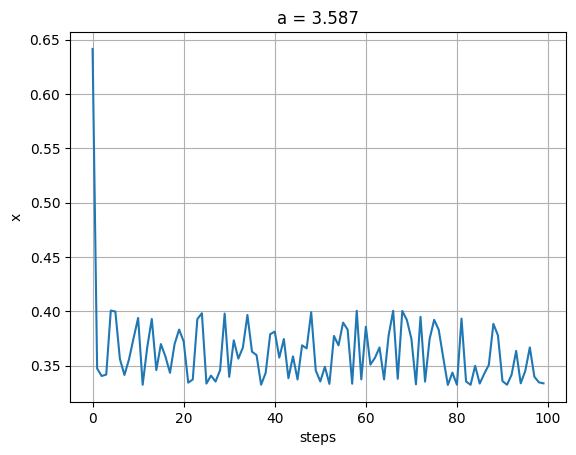

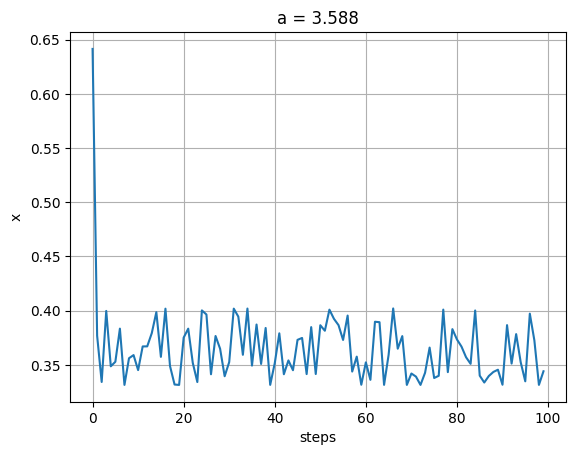

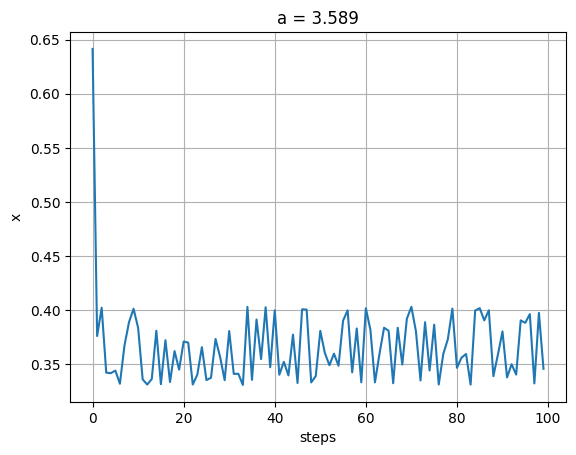

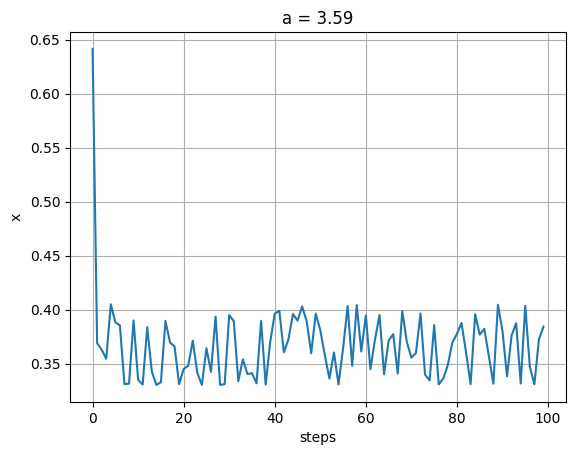

In [409]:
for a in np.arange(3.57, 3.59, 0.001):
    draw_process_chart(x0=X0, a=a, steps=6400, process=process, every=64)

Мы видим целую историю жизни процесса. Он стабилизируется, ловит период, после чего его разбалтывает. Опять ловит, и опять разбалтывает. Опять ловит..
При 3.5895 процесс чудом стабилизируется в одной позиции...

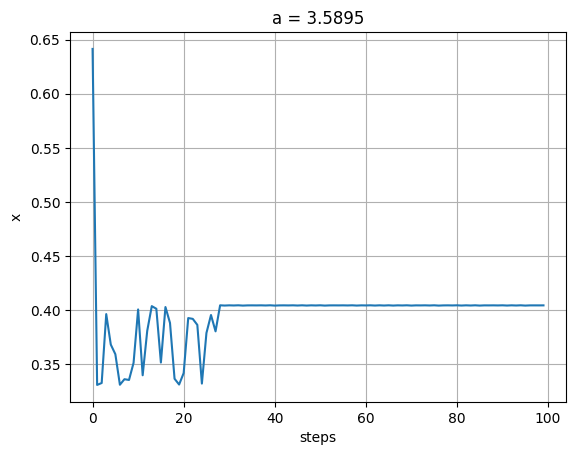

In [410]:
draw_process_chart(x0=X0, a=3.5895, steps=1600, process=process, every=16)

И его окончательно расколбашивает.

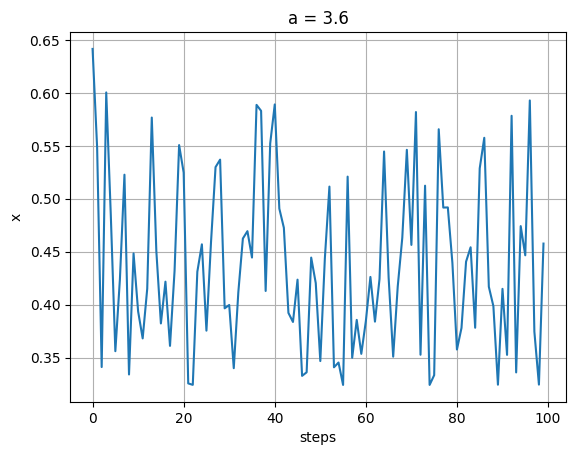

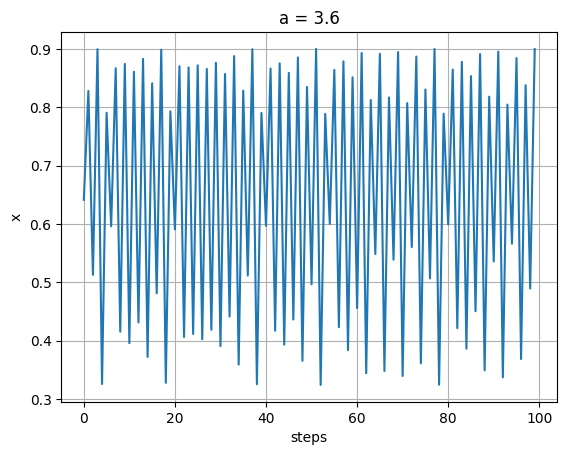

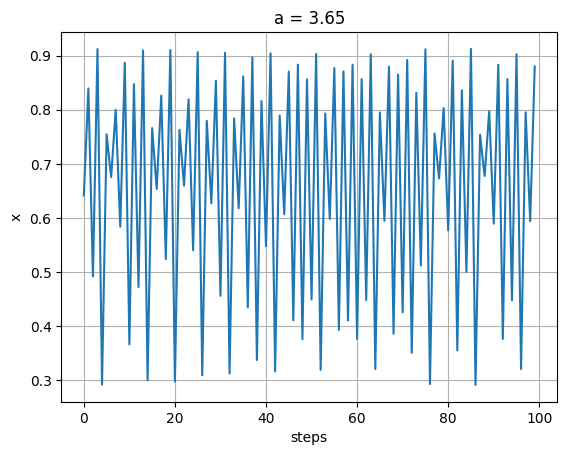

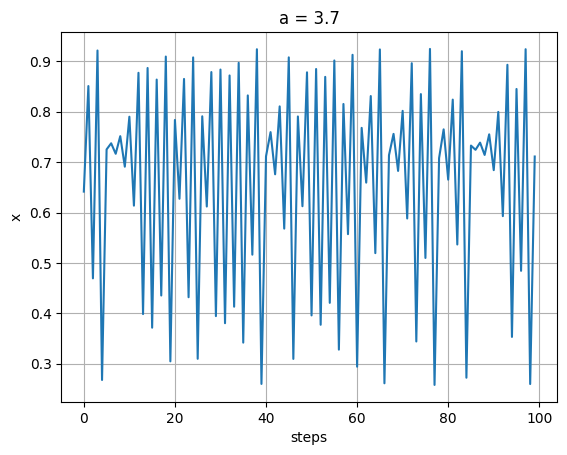

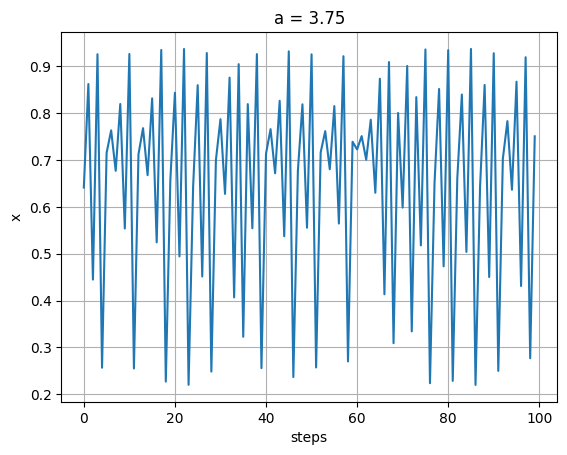

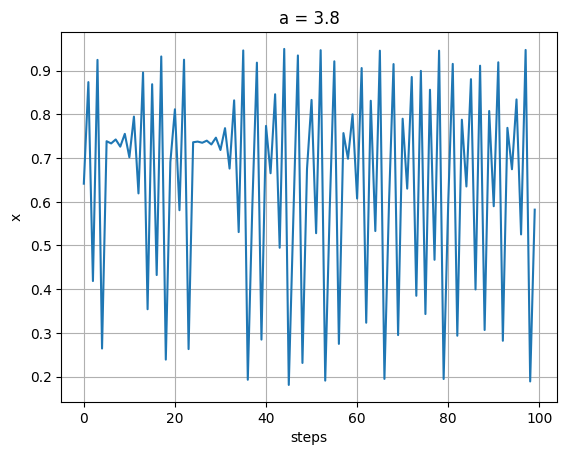

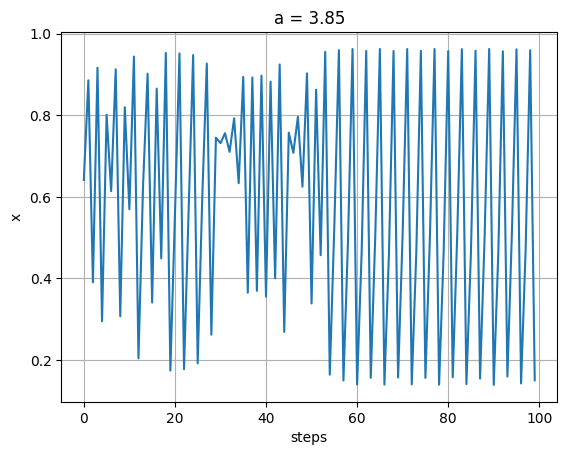

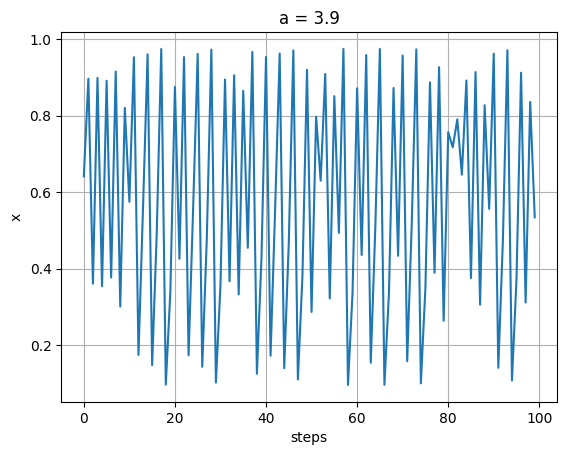

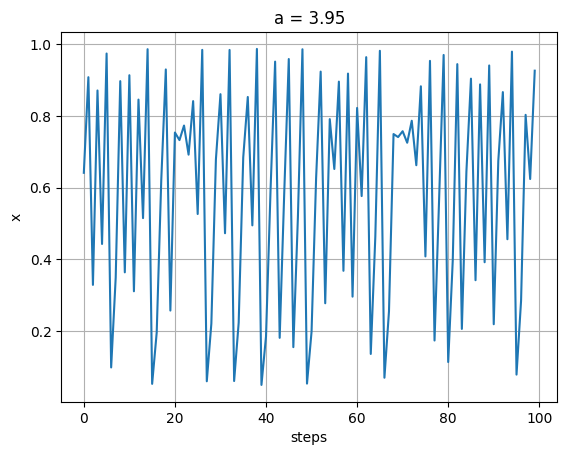

In [411]:
draw_process_chart(x0=X0, a=3.6, steps=6400, process=process, every=64)

for a in np.arange(3.6, 4, 0.05):
    draw_process_chart(x0=X0, a=a, steps=100, process=process)

А что будет после 4? Рассмотрим эволюцию процесса:

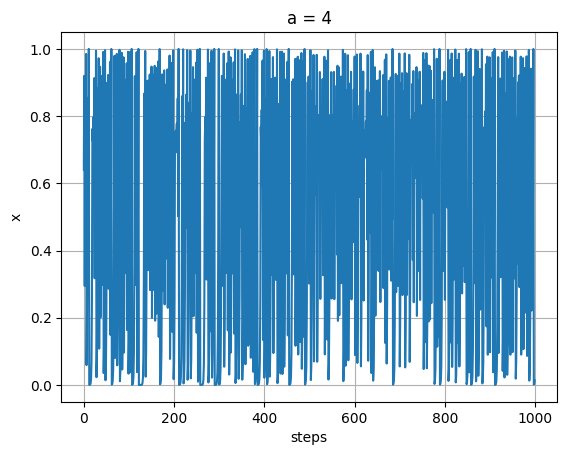

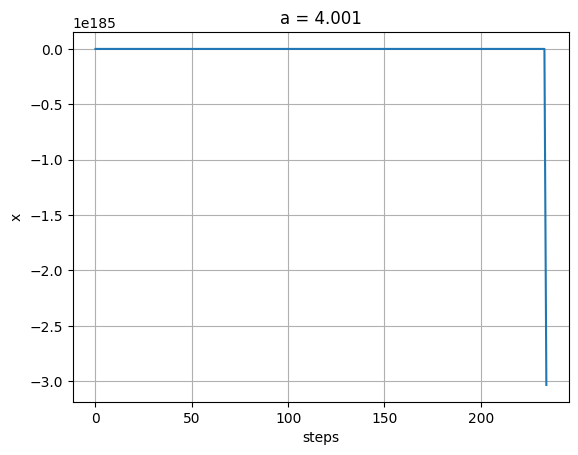

In [412]:
draw_process_chart(x0=X0, a=4, steps=1000, process=process)
draw_process_chart(x0=X0, a=4.001, steps=1000, process=process)

Как видно, процесс после 4 вылетает за разрешенный интервал [0,1] и дальше улетает в бесконечность.
(при некоторых x0 не улетает, вам может повезти)

**Промежуточный вывод:** Мы наблюдали "биографию" процесса от рождения до смерти.
Теперь нужен более систематический подход для анализа этого поведения.

## Глава вторая. Орбитальное движение

Просмотр отдельных графиков дал нам интуицию, но теперь нужен инструмент для
систематического анализа. Введем понятие *орбиты* - множества точек, к которым
стремится процесс после переходного периода.

Введем функцию orbit(process, a, x0), вычисляющую *стабильную орбиту* процесса при разных значениях а. (при произвольном x0 от 0 до 1)

Орбитой называются те точки, рядом с которыми будут проходить значения функции по истечении достаточного для стабилизации числа шагов. Мы видили, что:

orbit(process, 2, 0.5) = {0.5}

orbit(process, 3.4, 0.5) = {0.84215, 0.45196} , так как там значения болтаются между двумя точками

а стабильной орбита для 3.8 вовсе не существует (как вариант, она включает бесконечное множество точек)

In [413]:
def orbit(process, a, x0):
    SKIP = 128
    STEPS = 128

    EPS = 0.001

    x = x0

    # пропускаем первые SKIP шага, что бы орбита стабилизировалась
    for _ in range(SKIP):
        x = process(x, a)
        if abs(x) > 1e10:
            break

    # Собираем следующие STEPS шагов для анализа 
    values = []

    for _ in range(STEPS):
        x = (process(x, a)) #abs
        values.append(x)
        if abs(x) > 1e10:
            break


    # Сортируем их и разбиваем на группы

    values.sort()
    
    groups = [[]]

    for x in values:
        group = groups[-1]
        if len(groups[-1]) == 0:
            group.append(x)
            continue

        prev = group[-1]
        if x - prev < EPS:
            group.append(x)
            continue

        groups.append([x])

    return [np.mean(group) for group in groups]    

In [414]:
for a in np.arange(2, 4, 0.1):
    o = orbit(process, a, 0.5)
    print(round(a,5), len(o), o)

2.0 1 [np.float64(0.5)]
2.1 1 [np.float64(0.5238095238095238)]
2.2 1 [np.float64(0.5454545454545455)]
2.3 1 [np.float64(0.5652173913043478)]
2.4 1 [np.float64(0.5833333333333336)]
2.5 1 [np.float64(0.5999999999999999)]
2.6 1 [np.float64(0.6153846153846152)]
2.7 1 [np.float64(0.6296296296296298)]
2.8 1 [np.float64(0.642857142857143)]
2.9 1 [np.float64(0.6551724141384957)]
3.0 2 [np.float64(0.6494628632076138), np.float64(0.683057521702974)]
3.1 2 [np.float64(0.5580141252026952), np.float64(0.7645665199585948)]
3.2 2 [np.float64(0.5130445095326294), np.float64(0.7994554904673705)]
3.3 2 [np.float64(0.47942701982423375), np.float64(0.8236032832060693)]
3.4 2 [np.float64(0.451963247622239), np.float64(0.842154399434353)]
3.5 4 [np.float64(0.38281968301732344), np.float64(0.5008842103072184), np.float64(0.8269407065914385), np.float64(0.8749972636024644)]
3.6 87 [np.float64(0.3244166643157713), np.float64(0.32733086175066867), np.float64(0.3287180258370148), np.float64(0.33023309667560435),

Эта функция работает, но анализировать множество чисел неудобно.
Давайте визуализируем поведение орбит для всего диапазона параметра *a* одновременно.

Нарисуем *диаграмму орбит* - двумерный график, где по горизонтали откладывается
параметр a, а по вертикали - все точки орбиты для этого параметра.

In [415]:
def draw_orbit_chart(a_range, x0, process):
    values_count = 1000
    a_values = np.linspace(*a_range, values_count)

    As = []
    Xs = []

    for a in a_values:
        for x in orbit(process, a, x0):
            
            As.append(a)
            Xs.append(x)

    fig, ax = plt.subplots()
    
    ax.plot(As, Xs, 'b,')

    ax.set_xlabel('a')
    ax.set_ylabel('x')

    plt.show()    

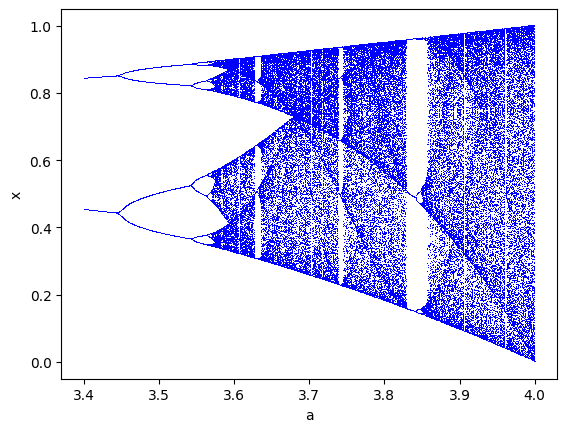

In [416]:
draw_orbit_chart([3.4,4], 0.5, process)

Это диаграмма бифуркаций Фейгенбаума.

In [417]:
# Каждая кривая — x_n(a) для своего x0; цвет показывает начальное значение.
# На шаге 0 виден исходный пучок, затем — результат n итераций процесса.
# Если нужно, установите виджеты в отдельной ячейке: %pip install ipywidgets
from ipywidgets import IntSlider, interact
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


@interact(step=IntSlider(
    value=0,
    min=0,
    max=100,
    step=1,
    description='Шаг n',
    continuous_update=False,
))
def logistic_bundle_demo(step):

    a_min = 3
    a_max = 4

    a_values = np.linspace(a_min, a_max, 1001)

    center = 0.5
    spread = 0.4
    count = 110

    x0_values = np.arange(0, count) / count * spread*2 + (center-spread)  # 0.01, 0.02, ..., 0.99
    x_values = np.broadcast_to(
        x0_values[:, None], (len(x0_values), len(a_values))
    ).copy()

    # Считаем все начальные значения и параметры a одновременно.
    for _ in range(step):
        x_values = process(x_values, a_values)

    cmap = plt.get_cmap('jet')
    norm = Normalize(vmin=x0_values[0], vmax=x0_values[-1])
    # Оставляем только явный показ графика, чтобы избежать двойного вывода.
    with plt.ioff():
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_prop_cycle(color=cmap(norm(x0_values)))
        ax.plot(a_values, x_values.T, marker='.', linestyle='None',  alpha=0.5)
        ax.set(xlim=(a_min, a_max), ylim=(0, 1), xlabel='a', ylabel=r'$x_n$',
               title=f'Пучок траекторий: шаг n = {step}')
        ax.grid(alpha=0.25)
        fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                     label=r'Начальное значение $x_0$')
        fig.tight_layout()
        plt.show()
        plt.close(fig)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Шаг n'), Output()), _dom_classe…

Напомним, что наш процесс: x → a · x · (1 - x)

Можно выделить несколько характерных областей поведения:

* При а от 0 до 1 процесс сходится к 0.
* При а от 1 и почти до 3 процесс сходится к ненулевому корню уравнения x = a * x * (1 - x).

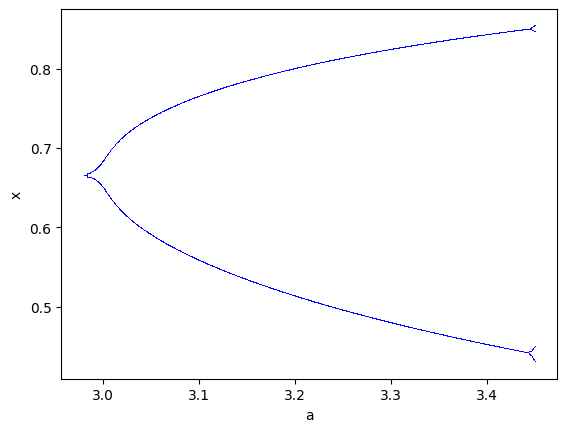

In [418]:
draw_orbit_chart([2.98,3.45], 0.5,process)

* Начиная примерно с 2.98 и до примерно 3.45 процесс сходится к *двум* значениям.

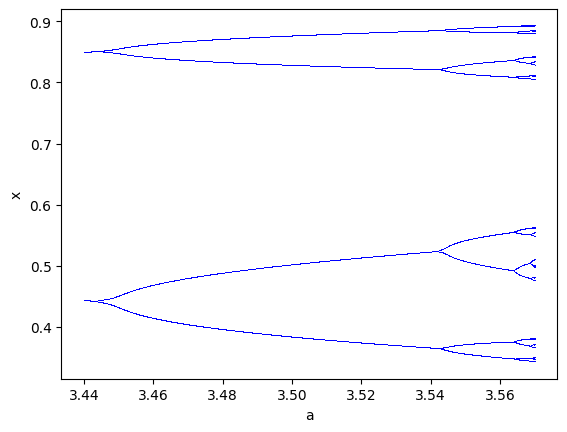

In [419]:
draw_orbit_chart([3.44,3.57], 0.5,process)

* Начиная с 3.45, орбита постоянно раздваивается (2 → 4 → 8 → 16...), пока около 3.57 последовательность бифуркаций не сходится. После этого начинается хаотическое поведение!

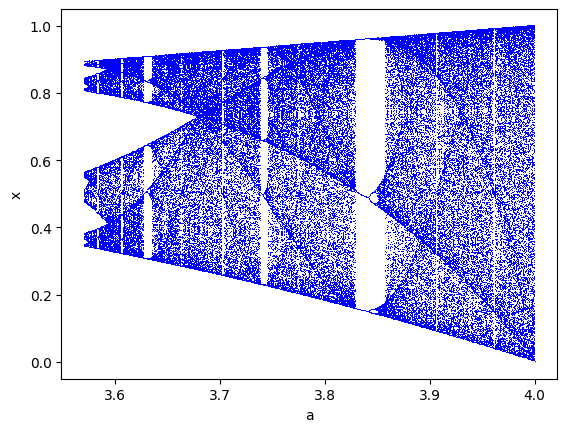

In [420]:
draw_orbit_chart([3.57,4], 0.5,process)

Мы можем наблюдать в некоторых диапазонах среди хаоса некие островки порядка. Самый крупный из их находится примерно в 3.828 - 3.858 и имеет длину орбиты 3. Внутри него тоже происходят удвоения периодов, причем каждая из трех ветвей в районе 3.85 погружается в свой собственный хаос.

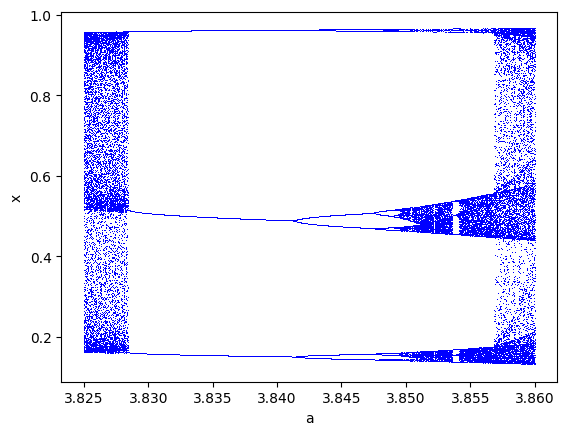

In [421]:
draw_orbit_chart([3.825,3.86], 0.5,process)

**Терминология:**
- Удвоение периода орбиты называется *бифуркацией*
- Бесконечная сходящаяся серия удвоений - *каскадом бифуркаций*
- Область хаотического поведения - *хаосом* или *странным аттрактором*

Вернемся к первому каскаду бифуркаций процесса:

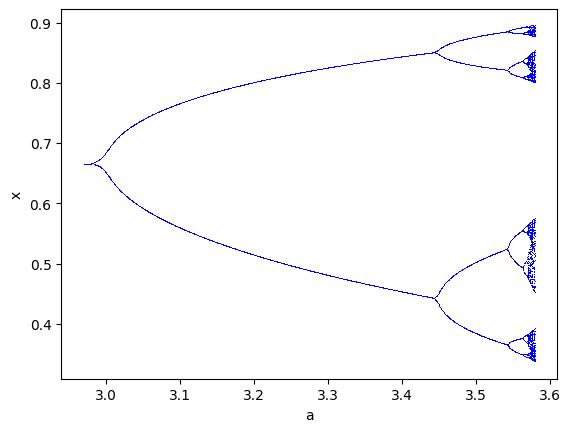

In [422]:
draw_orbit_chart([2.97,3.58], 0.5,process)

Зададим приблизительно точки бифуркаций

In [423]:
biffurcation = [
    3,
    3.44, 
    3.541, 
    3.564, 
    3.568, 
    3.57,
]

Удостоверимся, что это они

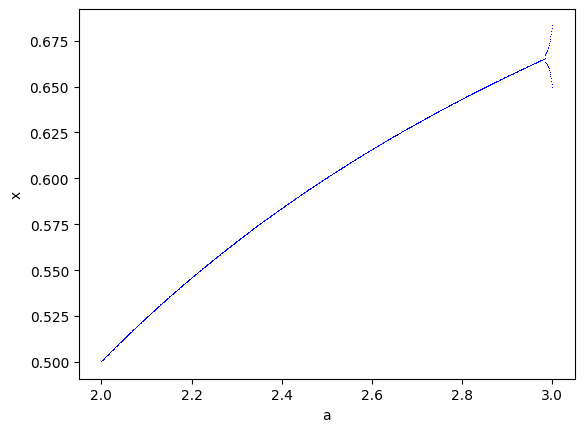

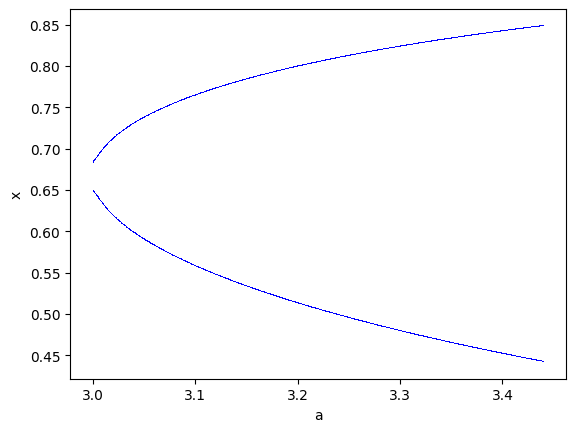

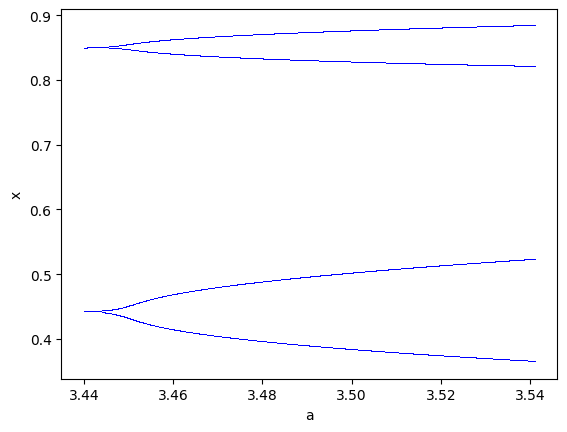

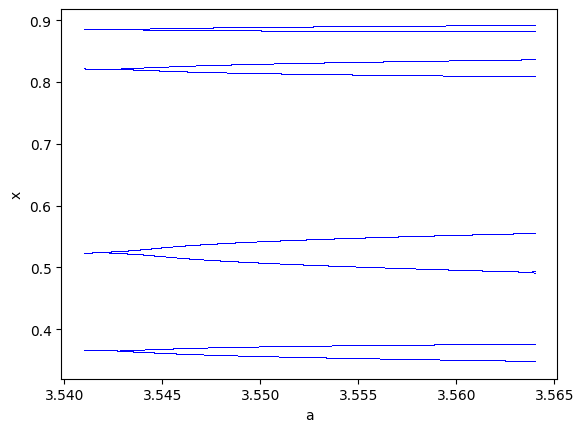

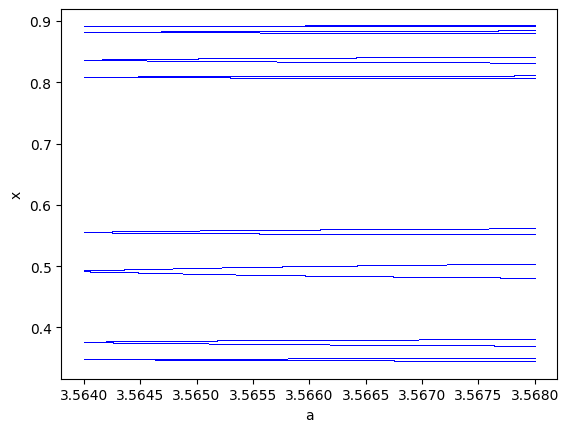

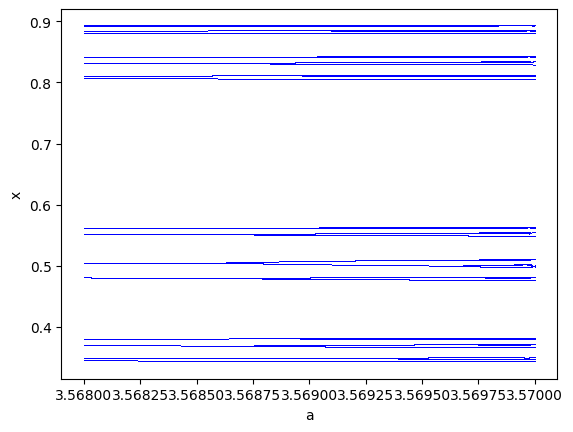

In [424]:
p = 2
for b in biffurcation:
    draw_orbit_chart([p, b], 0.5,process)
    p = b

Рассмотрим точки последовательных бифуркаций:
- a₁ = 3.000 (первая бифуркация: 1 → 2)
- a₂ = 3.440 (вторая бифуркация: 2 → 4)
- a₃ = 3.541 (третья бифуркация: 4 → 8)
- a₄ = 3.564 (четвертая: 8 → 16)
- a₅ = 3.568 (пятая: 16 → 32)
- a₆ ≈ 3.570 (шестая: 32 → 64)
- ...
- a∞ ≈ 3.5699456... (точка накопления)

Дистанция между соседними бифуркациями уменьшается в геометрической прогрессии.

Основание этой прогрессии (вернее, обратное к нему), сходится к *первой константе Фейгенбаума*, равной 4.669201...

А предел отношений между шириной ветвей - ко *второй константе Фейгенбаума*, равной 2.502907...

Природа этих констант и по сей день остается достаточно загадочной.

Удивительно, что эти константы *универсальны* - они появляются для всех
одномерных отображений с одним максимумом, независимо от конкретного вида функции!

## Глава третья. Устойчивость и показатель Ляпунова

### Устойчивость неподвижной точки

Почему при одних значениях параметра процесс сходится, а при других начинает колебаться?
Пусть $x_*$ — неподвижная точка: $f(x_*)=x_*$. Для малого отклонения
$\varepsilon_n=x_n-x_*$ разложение в первом порядке даёт

$$
\varepsilon_{n+1}\approx f'(x_*)\varepsilon_n.
$$

Если $|f'(x_*)|<1$, малые отклонения затухают; если $|f'(x_*)|>1$ — растут.
При $|f'(x_*)|=1$ этого приближения недостаточно для вывода об устойчивости.

Для логистического отображения $f(x)=ax(1-x)$ имеем $f'(x)=a(1-2x)$.
В точке $x_*=0$ производная равна $a$, поэтому при $0\leq a<1$ ноль устойчив.
Для ненулевой неподвижной точки

$$
x_*=1-\frac1a,\qquad f'(x_*)=2-a.
$$

| Параметр | Поведение малых отклонений около $x_*$ |
|---|---|
| $1<a<2$ | Уменьшаются без смены знака |
| $a=2$ | Линейный член исчезает: сверхустойчивая точка |
| $2<a<3$ | Меняют знак и уменьшаются: затухающие колебания |
| $a>3$ | Растут: неподвижная точка неустойчива |

При $a=3$ множитель достигает $-1$: здесь начинается первое удвоение периода.
Неустойчивость неподвижной точки ещё не означает хаос — сначала возникает устойчивый цикл периода 2.

### Две близкие траектории

Сравним начальные условия $x_0=0.31$ и $y_0=x_0+10^{-10}$.
Слева показаны сами траектории, справа — расстояние $d_n=|x_n-y_n|$ в логарифмическом масштабе.

При $a=2.8$ ожидаем сближение к неподвижной точке, при $a=3.2$ — к одному и тому же двухточечному циклу,
а при $a=3.9$ — усиление начального различия. Сравниваем точки на одинаковых шагах.

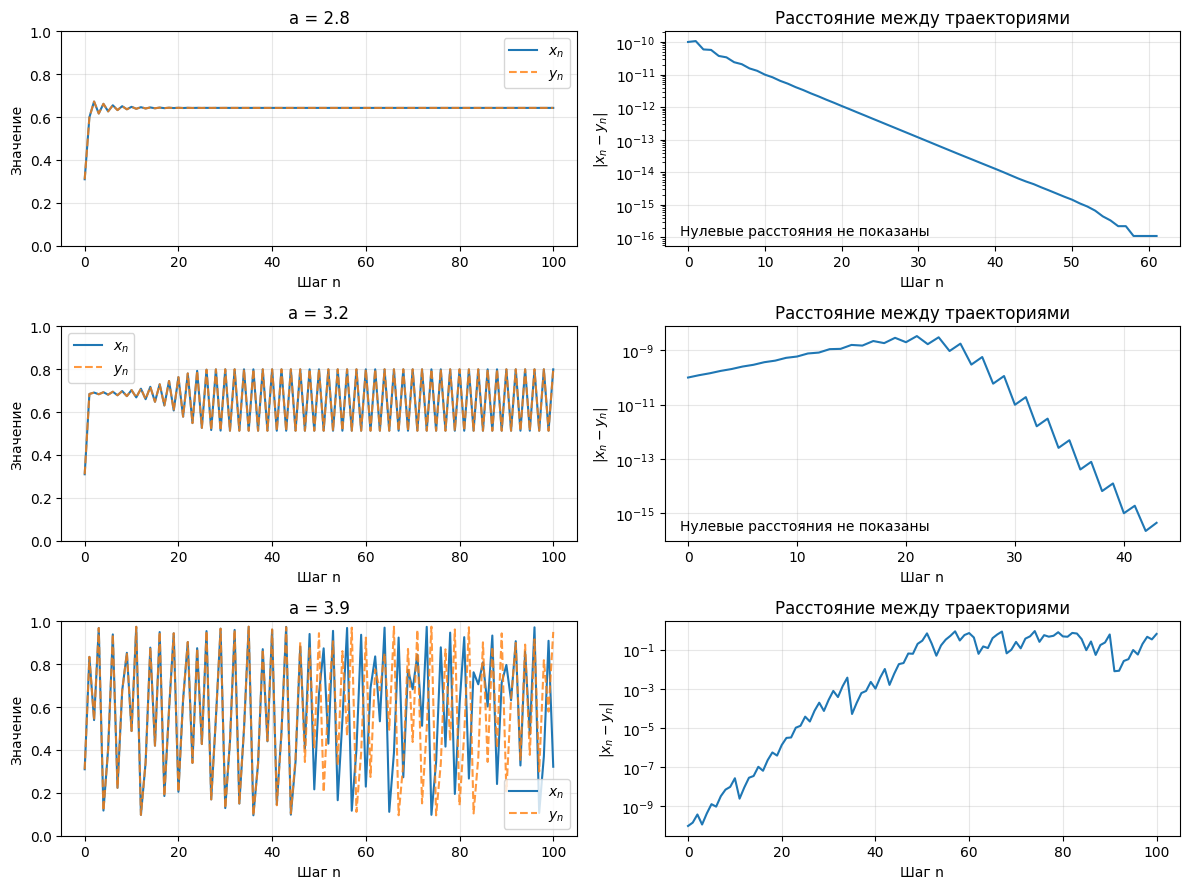

In [425]:
def compare_close_trajectories(a_values=(2.8, 3.2, 3.9), x0=0.31, delta=1e-10, steps=100):
    fig, axes = plt.subplots(len(a_values), 2, figsize=(12, 3 * len(a_values)), squeeze=False)
    ns = np.arange(steps + 1)

    for row, a in enumerate(a_values):
        xs = np.empty(steps + 1)
        ys = np.empty(steps + 1)
        xs[0], ys[0] = x0, x0 + delta
        for n in range(steps):
            xs[n + 1] = process(xs[n], a)
            ys[n + 1] = process(ys[n], a)

        ax, distance_ax = axes[row]
        ax.plot(ns, xs, label=r'$x_n$')
        ax.plot(ns, ys, '--', label=r'$y_n$', alpha=0.8)
        ax.set(title=f'a = {a}', xlabel='Шаг n', ylabel='Значение', ylim=(0, 1))
        ax.legend()

        distances = np.abs(xs - ys)
        # Нулевые расстояния не определены на логарифмической шкале.
        distance_ax.semilogy(ns, np.where(distances > 0, distances, np.nan))
        distance_ax.set(title='Расстояние между траекториями', xlabel='Шаг n', ylabel=r'$|x_n-y_n|$')
        if np.any(distances == 0):
            distance_ax.text(0.03, 0.05, 'Нулевые расстояния не показаны', transform=distance_ax.transAxes)
        ax.grid(alpha=0.3)
        distance_ax.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()
    plt.close(fig)


compare_close_trajectories()

Пока расстояние мало, его типичный рост или спад можно описать приближением

$$
d_n\approx d_0e^{\lambda n}.
$$

На графике $\ln d_n$ это соответствует участку с наклоном около $\lambda$.
При хаосе рост не продолжается бесконечно: обе траектории остаются в $[0,1]$, и расстояние насыщается.
Совпадение чисел в компьютере также может обнулить расстояние в устойчивом режиме.

Для $\lambda>0$ ориентировочный горизонт прогноза с допустимой ошибкой $D$ равен
$n\approx\ln(D/d_0)/\lambda$ — в пределах применимости этого приближения.

### Показатель Ляпунова

Показатель Ляпунова измеряет среднюю скорость экспоненциального изменения малого возмущения вдоль траектории:

$$
\lambda=\lim_{N\to\infty}\frac1N\sum_{n=0}^{N-1}\ln|f'(x_n)|.
$$

Для логистического отображения $f'(x_n)=a(1-2x_n)$.

- $\lambda<0$: малые возмущения в среднем затухают.
- $\lambda>0$: малые возмущения в среднем растут; для типичной ограниченной траектории это признак хаоса.
- $\lambda=0$: экспоненциального роста или затухания нет; требуется дополнительный анализ.

Ниже считаем конечное среднее после пропуска переходного участка. Если производная в учитываемой точке равна нулю,
её вклад равен $\ln0=-\infty$, и пропускать его нельзя. В частности, при $a=2$ на неподвижной точке $x_*=0.5$
получаем $\lambda=-\infty$.

In [426]:
def lyapunov_exponent(process, a, x0=0.5, n_skip=100, n_steps=1000):
    """
    Вычисляет показатель Ляпунова для процесса
    
    Args:
        process: функция процесса f(x, a)
        a: параметр процесса
        x0: начальное значение
        n_skip: количество шагов для пропуска (установление режима)
        n_steps: количество шагов для усреднения
    
    Returns:
        λ: показатель Ляпунова
    """
    x = x0
    
    # Пропускаем начальный переходный процесс
    for _ in range(n_skip):
        x = process(x, a)
        if abs(x) > 1e10:
            return float('inf')
    
    # Вычисляем сумму логарифмов производных
    lyap_sum = 0
    
    for _ in range(n_steps):
        # Производная f(x, a) = a*x*(1-x) равна a*(1-2*x)
        derivative = abs(a * (1 - 2 * x))
        
        if derivative == 0:
            return float('-inf')
        lyap_sum += np.log(derivative)

        x = process(x, a)
        if abs(x) > 1e10:
            return float('inf')
    
    return lyap_sum / n_steps

Вычислим показатель Ляпунова для нескольких характерных значений a:

In [427]:
test_values = [1.5, 2.0, 2.5, 3.0, 3.2, 3.5, 3.57, 3.7, 3.8, 3.9, 4.0]

print("\nПоказатели Ляпунова для различных значений a:")
print("-" * 50)
for a in test_values:
    lyap = lyapunov_exponent(process, a, X0)
    print(f"a = {a:4.2f}  →  λ = {lyap:8.5f}  {'(хаос)' if lyap > 0 else '(порядок)'}")


Показатели Ляпунова для различных значений a:
--------------------------------------------------
a = 1.50  →  λ = -0.69315  (порядок)
a = 2.00  →  λ = -36.04365  (порядок)
a = 2.50  →  λ = -0.69315  (порядок)
a = 3.00  →  λ = -0.00276  (порядок)
a = 3.20  →  λ = -0.91629  (порядок)
a = 3.50  →  λ = -0.87251  (порядок)
a = 3.57  →  λ =  0.01032  (хаос)
a = 3.70  →  λ =  0.35238  (хаос)
a = 3.80  →  λ =  0.43924  (хаос)
a = 3.90  →  λ =  0.50406  (хаос)
a = 4.00  →  λ =  0.69349  (хаос)


Построим график показателя Ляпунова в зависимости от параметра a:

In [428]:
def draw_lyapunov_chart(a_range, x0, process, n_points=500):
    """
    Рисует график показателя Ляпунова в зависимости от параметра a
    """
    a_values = np.linspace(*a_range, n_points)
    lyap_values = []
    
    for a in a_values:
        lyap = lyapunov_exponent(process, a, x0)
        lyap_values.append(lyap)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(a_values, lyap_values, 'b-', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='λ = 0')
    ax.grid(True, alpha=0.3)
    
    ax.set_xlabel('Параметр a', fontsize=12)
    ax.set_ylabel('Показатель Ляпунова λ', fontsize=12)
    ax.set_title('Показатель Ляпунова для логистического отображения', fontsize=14)
    
    # Закрашиваем области
    ax.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) > 0, 
                     alpha=0.3, color='red', label='Хаос (λ > 0)')
    ax.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) <= 0, 
                     alpha=0.3, color='green', label='Порядок (λ < 0)')
    
    ax.legend()
    plt.show()

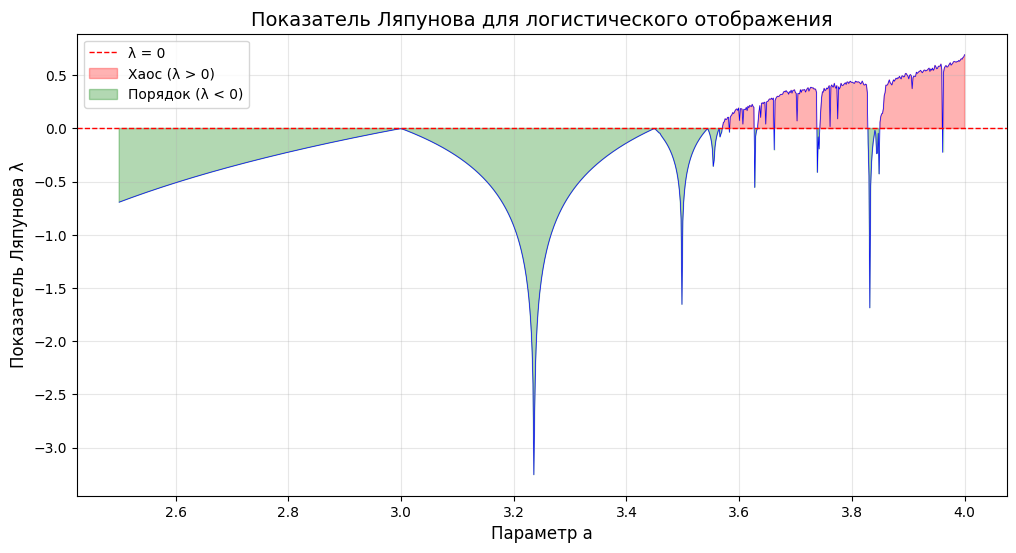

In [429]:
draw_lyapunov_chart([2.5, 4.0], X0, process, n_points=1000)

На устойчивых циклах показатель Ляпунова отрицателен, а в точках удвоения периода достигает нуля.
В сверхустойчивых циклах он равен $-\infty$; такие значения не отображаются как конечные точки на графике.
После накопления удвоений чередуются хаотические режимы с положительным показателем и окна периодичности
с отрицательным. Конечное число итераций даёт приближённую оценку, особенно около границ режимов.

Позже сопоставим этот график с диаграммой орбит и картиной в комплексной плоскости параметра.

## Глава четвёртая. Комплексные параметры и множество Мандельброта

Мы изучили поведение нашего процесса для вещественных значений параметра a.
Теперь сделаем смелый шаг: а что если рассмотреть *комплексные* значения параметра?

Это откроет нам совершенно новый взгляд на структуру устойчивости системы.

Когда современный математик видит некое загадочное явление, связанное с поведением функции, у него всегда есть соблазн посмотреть, что будет происходить, если в качестве аргументов функции подставить комплексные числа. Сделаем так и мы.

Будем исследовать устойчивость отображения x -> a * x * (1 - x) при разных (возможно, комплексных) а.

Разделим все возможные (комплексные) а на два множества.

А именно:
* если при неком а процесс имеет тенденцию убегать на бесконечность, поместим а в первое множество,
* если при некотором а процесс имеет тенденцию оставаться в пределах единичного круга, поместим а во второе множество.

Нарисуем картинку, раскрасив первое множество черным цветом, а второе - оттенком, в зависимости от зафиксированного момента убегания

In [430]:
def draw_mandelbrots_chart(a_range, color, ax=None):
    DPU = 600

    width  = a_range[0][1]-a_range[0][0]
    height = a_range[1][1]-a_range[1][0]

    if width < height:
        x_points, y_points = int(DPU*width/height), DPU
    else:
        x_points, y_points = DPU, int(DPU*height/width)

    xx = np.linspace(*a_range[0], x_points).reshape(1, -1)
    yy = np.linspace(*a_range[1], y_points)[::-1].reshape(-1, 1)
    zz = xx + 1j * yy
 
    zz = zz.ravel()

    calc_v = np.vectorize(color)

    image = calc_v(zz)

    image = np.reshape(image, (y_points, x_points))

    standalone = ax is None
    if standalone:
        _, ax = plt.subplots()

    # Координаты параметра вместо номеров пикселей позволяют совместить оси.
    ax.imshow(image, extent=[*a_range[0], *a_range[1]],
              origin='upper', cmap='hot')
    if standalone:
        ax.set_xticks(a_range[0])
        ax.set_yticks(a_range[1])
        plt.show()


Для этого нам потребуется функция раскраски, которую мы создадим из исходного процесса:

In [431]:
def color_bw(a):

    x0 = 0.5

    x = x0

    for _ in range(64):
        x = process(x, a)

        if abs(x) > 1:
            return 1

    return 0

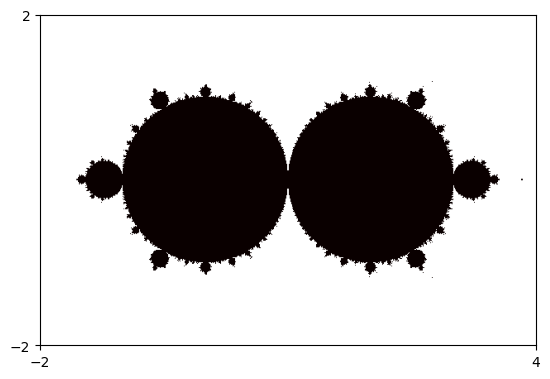

In [432]:
draw_mandelbrots_chart([[-2, 4], [-2, 2]], color_bw)

Что бы сделать картинку интереснее, можно раскрашивать белое множество дальше, в зависимости от того, на каком шаге произошел уход за разрешенный интервал. Так мы сделаем акцент на границе.

In [433]:
def color(a):

    x0 = 0.5

    x = x0

    for k in range(64):
        x = process(x, a)

        if abs(x) > 1:
            return 64-k

    return 0

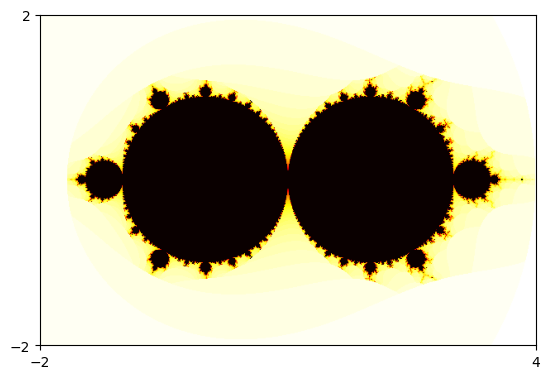

In [434]:
draw_mandelbrots_chart([[-2, 4], [-2, 2]], color)

Рассмотрим подробнее некоторые кусочки

In [435]:
biffurcation = [
    1,
    3,
    3.44,
    3.541, 
    3.564, 
]

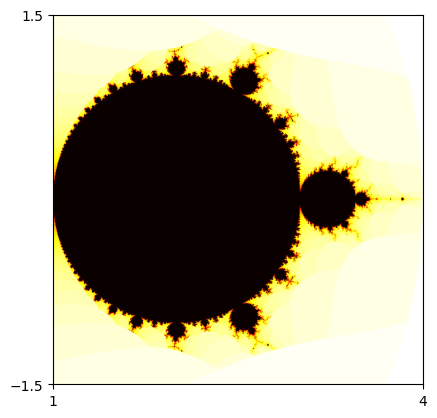

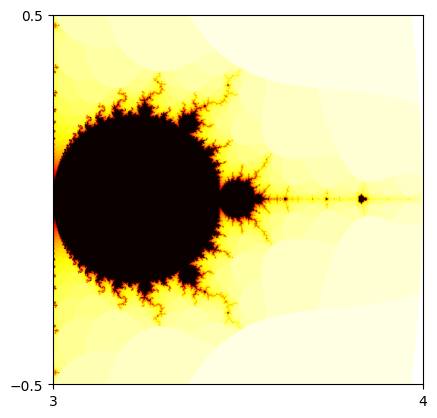

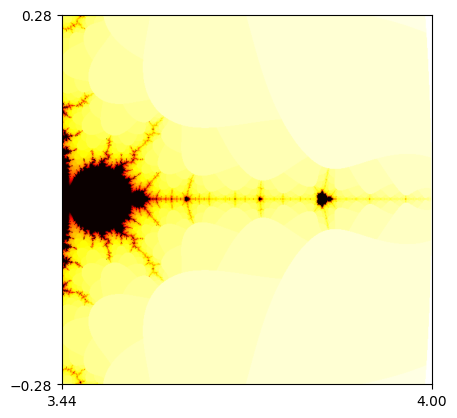

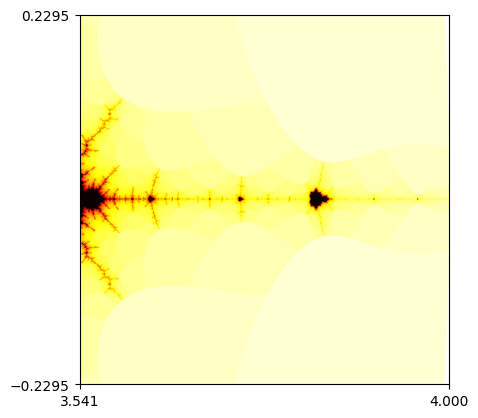

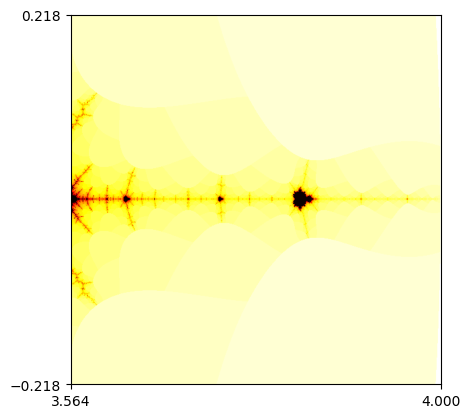

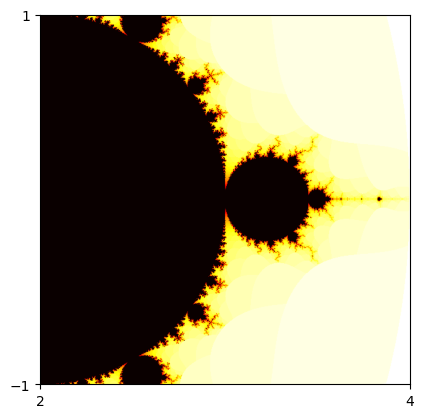

In [436]:
for b in biffurcation:
    draw_mandelbrots_chart([[b, 4], [-(4-b)/2, (4-b)/2]], color)

draw_mandelbrots_chart([[2, 4], [-1, 1]], color)

Сравним множество устойчивости с диаграммой орбит:

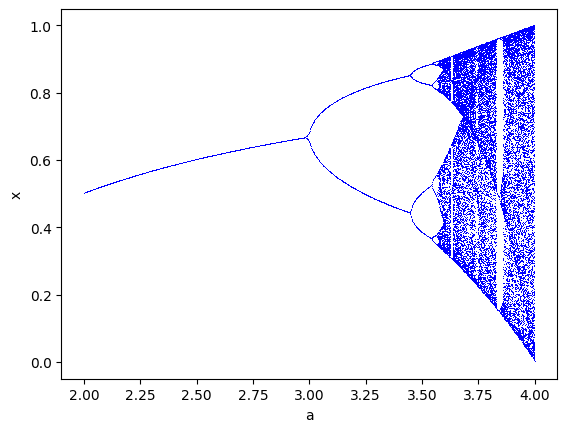

In [437]:
draw_orbit_chart([2,4], 0.5, process)

Обратите внимание: вещественная ось на комплексном изображении в точности
соответствует диаграмме орбит! Комплексное расширение показывает, что
структура устойчивости имеет фрактальную природу во всех направлениях.

### Связь с отображением $z^2+c$

При $a\ne0$ логистическое отображение можно привести к стандартному квадратичному виду заменой координат:

$$
z_n=a\left(\frac12-x_n\right),\qquad
z_{n+1}=z_n^2+c,\qquad c=\frac{a(2-a)}4.
$$

Это равенство проверяется прямой подстановкой. Критическая точка $x_0=0.5$, где $f'(x_0)=0$,
переходит в $z_0=0$. Стандартное множество Мандельброта — множество параметров $c$, для которых эта орбита ограничена.
Таким образом, соответствующая область ограниченности в плоскости $a$ — прообраз множества Мандельброта
при $c=a(2-a)/4$ (случай $a=0$ рассматривается отдельно: исходное отображение постоянно равно нулю).

Ограниченность не означает обязательной сходимости к точке: возможны циклы и хаотические траектории.
Картинки выше используют конечное число шагов и порог $|x|>1$, поэтому служат иллюстрацией,
а не точным тестом принадлежности этой области. Для критической орбиты в координате $z$ критерий ухода — $|z|>2$.

Логистическое отображение и $z^2+c$ связаны точной заменой координат.
Сравнение с синусным отображением в следующей главе показывает сходные закономерности уже для другой формы функции.

## Глава пятая. Универсальность хаоса

Удивительный факт: поведение, которое мы наблюдали для логистического отображения,
*универсально* для широкого класса нелинейных систем!

Константы Фейгенбаума и каскад бифуркаций появляются в любых гладких
одномерных отображениях с одним максимумом. Продемонстрируем это на других функциях.

Рассмотрим ещё две функции: `x -> a*sin(pi*x)` и `x -> x^2 + a`

In [438]:
def process1(x, a):
    return x**2 + a

In [439]:
def color1(a):

    x0 = 0

    x = x0

    for k in range(64):
        x = process1(x, a)

        if abs(x) > 2:
            return k

    return 0

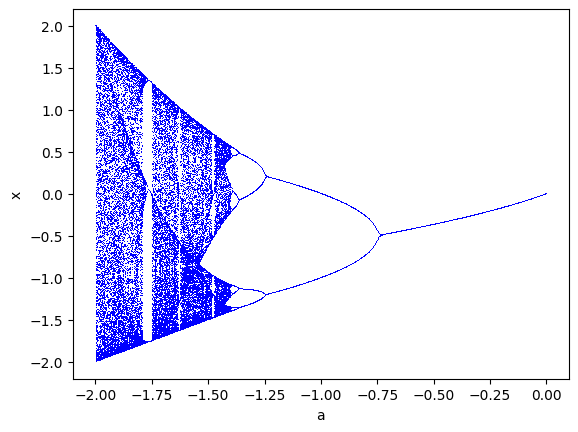

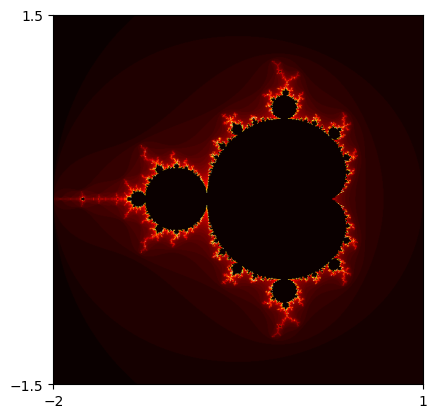

In [440]:
draw_orbit_chart([-2,0], 0, process1)

draw_mandelbrots_chart([[-2, 1], [-1.5, 1.5]], color1)

In [441]:
def process2(x, a):
    return a * np.sin(np.pi*x)

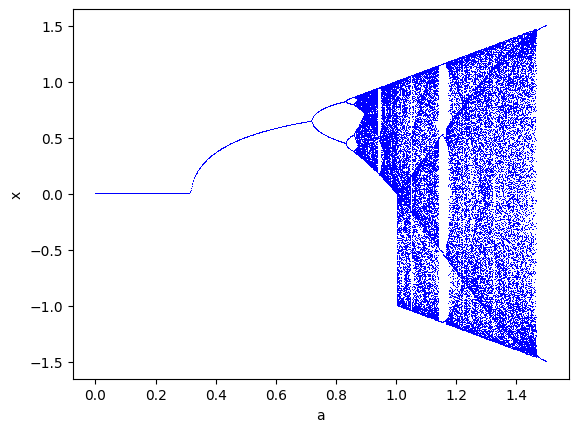

In [442]:
draw_orbit_chart([0,1.5], 0.5, process2)

In [443]:
def color2(a):

    x0 = 0.5

    x = x0

    for k in range(64):
        x = process2(x, a)

        if abs(x) > 10:
            return k

    return 64

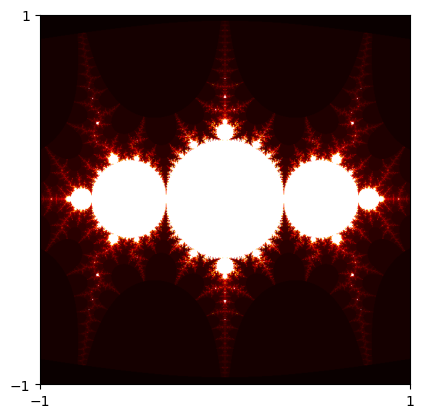

In [444]:
draw_mandelbrots_chart([[-1, 1], [-1, 1]], color2)

**Вывод:** Все три функции демонстрируют:
- Каскад бифуркаций
- Переход к хаосу через удвоение периода
- Фрактальную структуру границы устойчивости
- Окна периодичности в хаотической области

Это подтверждает **универсальность** открытых нами закономерностей!

## Глава шестая. Множество Джулиа

В четвёртой главе мы исследовали устойчивость при различных значениях параметра a.
Теперь перевернем вопрос: зафиксируем параметр a и исследуем, как влияет
выбор *начального условия* на поведение системы.

Это приведет нас к понятию *множества Джулиа* - одному из самых красивых
объектов в математике.

**Идея:** Вместо варьирования параметра a при фиксированном x₀,
теперь зафиксируем параметр a и будем варьировать начальное условие x₀.

Для каждого процесса мы можем построить *множество Джулиа* - множество начальных точек в комплексной плоскости,
при которых процесс остается ограниченным.

Граница этого множества имеет фрактальную структуру и демонстрирует самоподобие.

In [445]:
def draw_julia_set(a, x_range, y_range, max_iter=64, threshold=10):
    """
    Рисует множество Джулиа для процесса x -> a*x*(1-x) при фиксированном a
    
    Args:
        a: параметр процесса (может быть комплексным)
        x_range: диапазон [xmin, xmax] для реальной части
        y_range: диапазон [ymin, ymax] для мнимой части
        max_iter: максимальное число итераций
        threshold: порог ухода на бесконечность
    """
    DPU = 800
    
    width = x_range[1] - x_range[0]
    height = y_range[1] - y_range[0]
    
    if width < height:
        x_points, y_points = int(DPU * width / height), DPU
    else:
        x_points, y_points = DPU, int(DPU * height / width)
    
    xx = np.linspace(*x_range, x_points).reshape(1, -1)
    yy = np.linspace(*y_range, y_points)[::-1].reshape(-1, 1)
    z0 = xx + 1j * yy
    
    z = z0.copy()
    image = np.zeros(z.shape)
    
    for k in range(max_iter):
        # Применяем процесс
        z = a * z * (1 - z)
        
        # Находим точки, которые ушли на бесконечность
        mask = (np.abs(z) > threshold) & (image == 0)
        image[mask] = k
    
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.title(f'Множество Джулиа для a = {a}')
    
    ax.set_xlabel('Re(x)')
    ax.set_ylabel('Im(x)')
    
    # Используем цветовую схему для визуализации скорости ухода
    plt.imshow(image, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
               cmap='summer', origin='lower')
    plt.colorbar(label='Итерации до ухода')
    plt.show()

Рассмотрим множество Джулиа для нескольких характерных значений параметра a:

In [446]:
# Два ползунка задают комплексный параметр a = Re(a) + i Im(a).
# Если нужно, установите виджеты в отдельной ячейке: %pip install ipywidgets
from ipywidgets import FloatSlider, interact


@interact(
    a_real=FloatSlider(value=2.0, min=-4.0, max=4.0, step=0.05,
                       description='Re(a)', readout_format='.2f',
                       continuous_update=False),
    a_imag=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.05,
                       description='Im(a)', readout_format='.2f',
                       continuous_update=False),
)
def julia_demo(a_real, a_imag):
    a = complex(a_real, a_imag)
    max_iter = 64
    coordinates = np.linspace(-2.0, 2.0, 500)
    # Строки идут снизу вверх, как и изображение при origin='lower'.
    z = coordinates[None, :] + 1j * coordinates[:, None]
    escape_steps = np.zeros(z.shape, dtype=int)
    active = np.ones(z.shape, dtype=bool)
    # За этим радиусом модуль гарантированно растёт при a != 0.
    escape_radius = max(10.0, 1.0 + 1.0 / abs(a)) if a != 0 else 10.0

    for step in range(1, max_iter + 1):
        # Ушедшие точки больше не вычисляем, чтобы избежать переполнения.
        current = z[active]
        z[active] = a * current * (1 - current)
        escaped = active & (np.abs(z) > escape_radius)
        escape_steps[escaped] = step
        active[escaped] = False
        if not active.any():
            break

    # Ноль означает: точка не ушла за max_iter шагов (чёрный цвет).
    with plt.ioff():
        fig, ax = plt.subplots(figsize=(8, 7))
        image = ax.imshow(escape_steps, extent=[-2, 2, -2, 2],
                          origin='lower', cmap='hot', vmin=0, vmax=max_iter,
                          interpolation='nearest')
        ax.set(xlabel='Re(x)', ylabel='Im(x)',
               title=f'Множество Джулиа: a = {a.real:.2f}{a.imag:+.2f}i')
        fig.colorbar(image, ax=ax, label='Итерации до ухода (0 — не ушла за 64 шага)')
        fig.tight_layout()
        plt.show()
        plt.close(fig)


interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='Re(a)', max=4.0, min=-4.0, …

### a = 2 (точка стабилизации)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


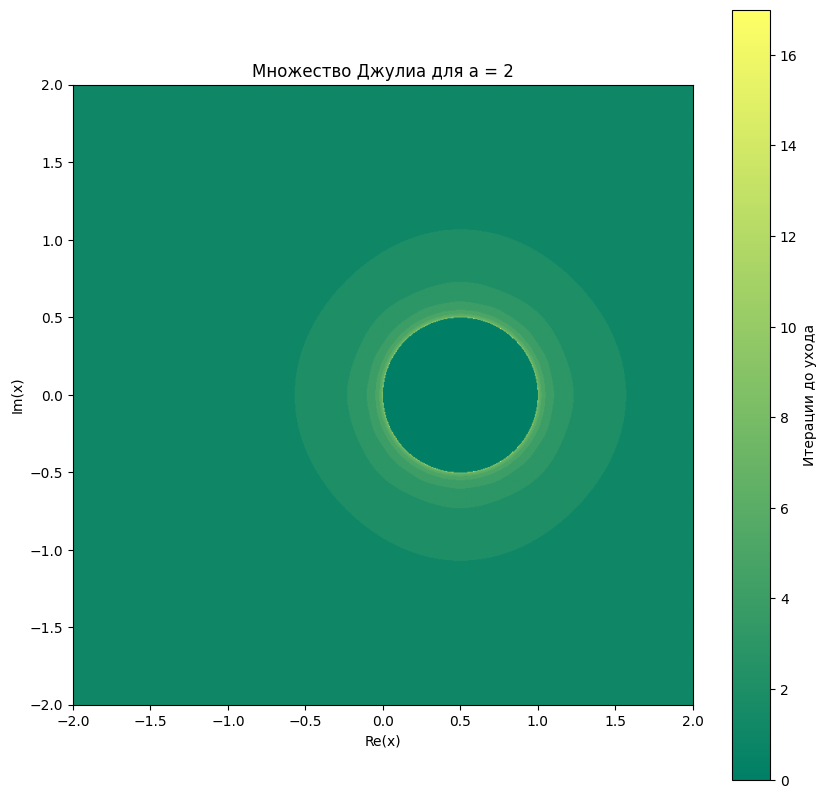

In [447]:
draw_julia_set(2, [-2, 2], [-2, 2])

### a = 3 (перед первой бифуркацией)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


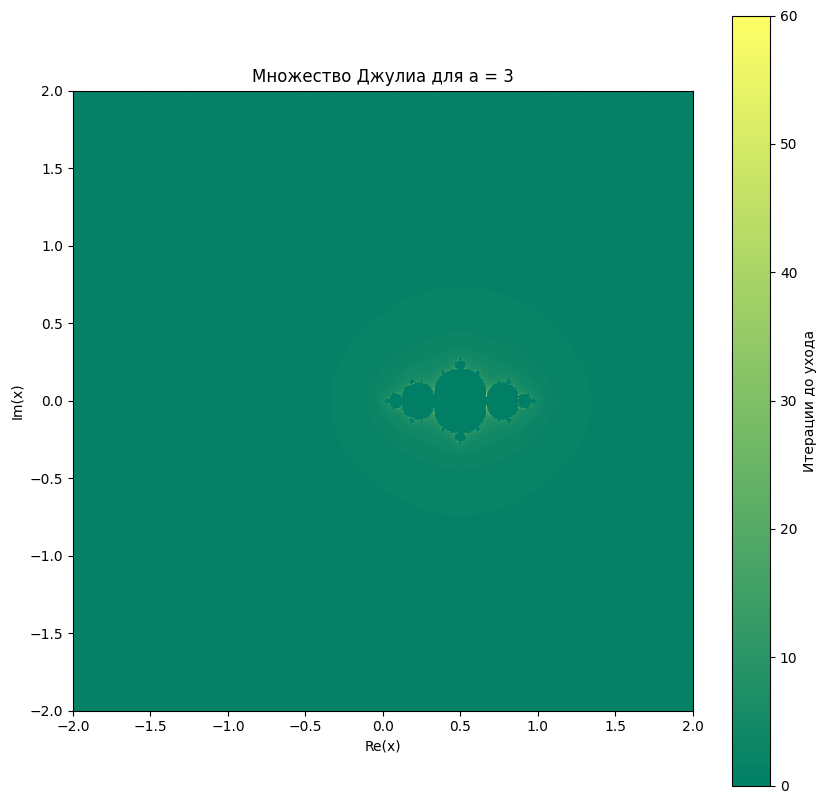

In [448]:
draw_julia_set(3, [-2, 2], [-2, 2])

### a = 3.5 (в области удвоения периода)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


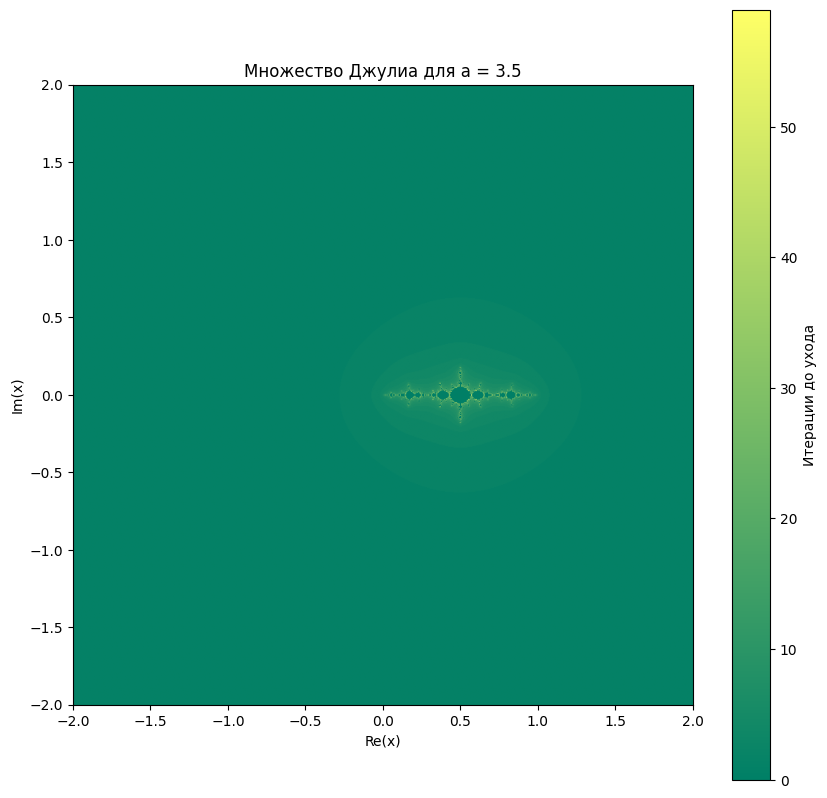

In [449]:
draw_julia_set(3.5, [-2, 2], [-2, 2])

### a = 3.8 (хаотический режим)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


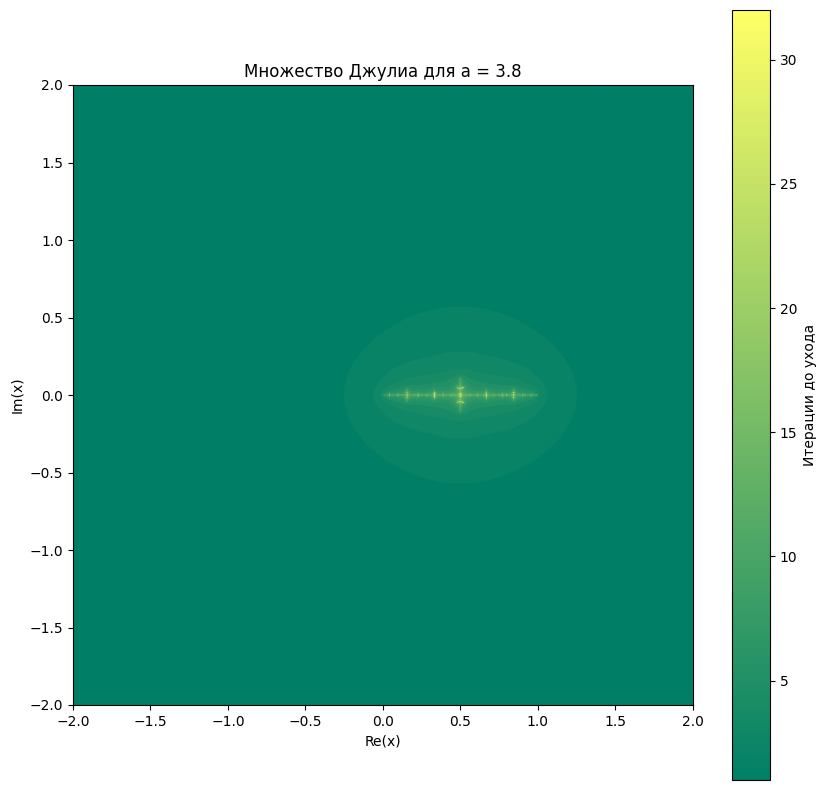

In [450]:
draw_julia_set(3.8, [-2, 2], [-2, 2])

### a = 4 (граница устойчивости)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


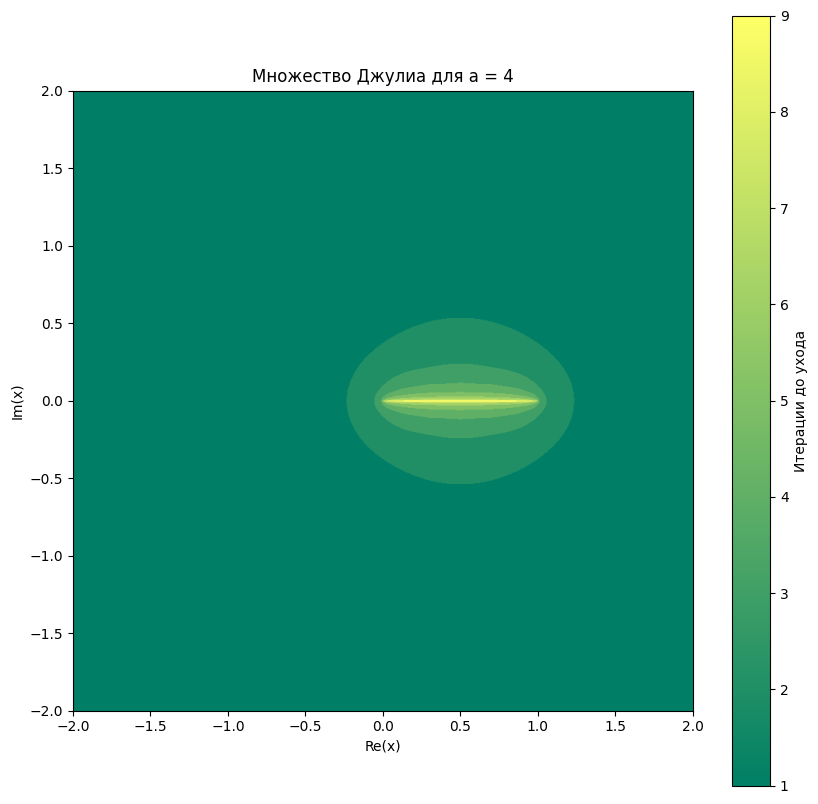

In [451]:
draw_julia_set(4, [-2, 2], [-2, 2])

Особенно интересно смотреть на комплексные значения параметра a:

### a = 3 + 0.5i (комплексный параметр)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


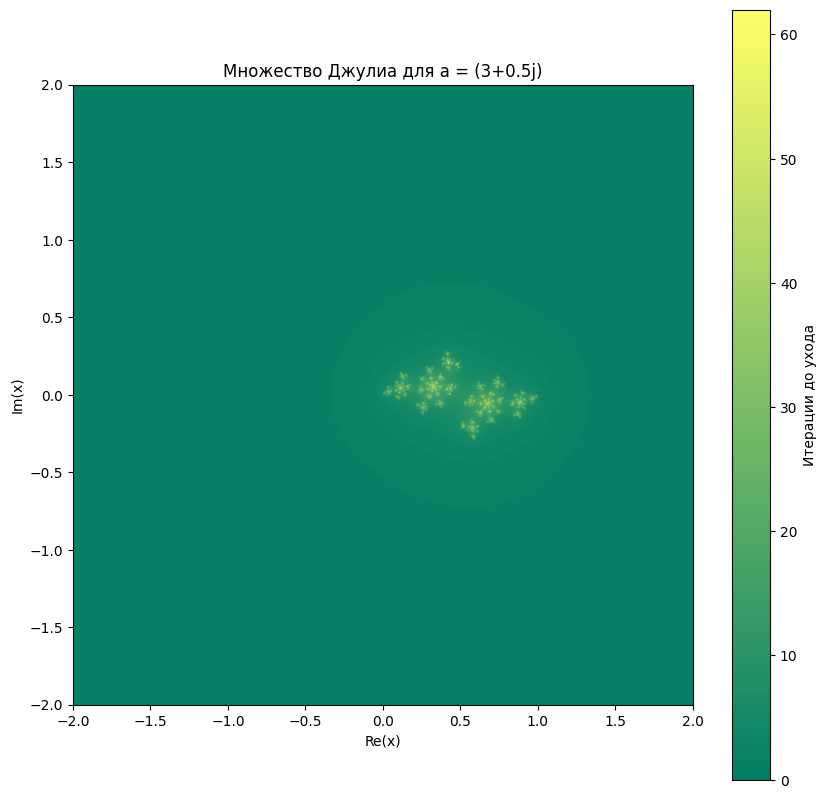

In [452]:
draw_julia_set(3 + 0.5j, [-2, 2], [-2, 2])

### a = 2 + 1i (комплексный параметр)

C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: overflow encountered in multiply
  z = a * z * (1 - z)
C:\Users\admin\AppData\Local\Temp\ipykernel_36848\628524744.py:31: RuntimeWarning: invalid value encountered in multiply
  z = a * z * (1 - z)


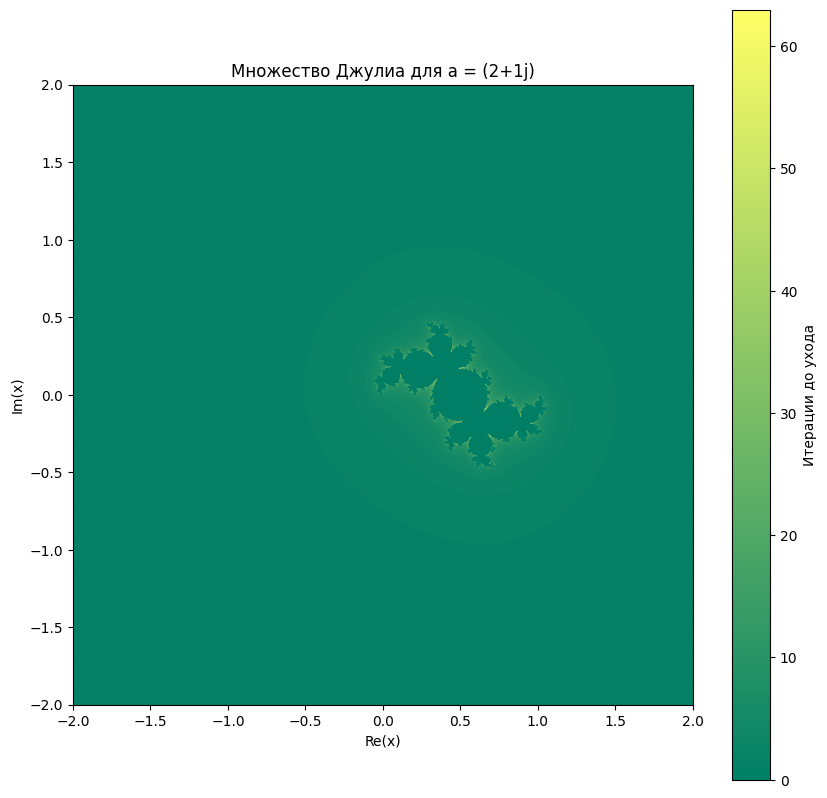

In [453]:
draw_julia_set(2 + 1j, [-2, 2], [-2, 2])

Можно заметить, что структура множества Джулиа связана с поведением процесса:
- В области стабильности множество имеет простую связную структуру
- В области бифуркаций появляются сложные фрактальные структуры
- В хаотическом режиме множество становится несвязным (пыль Кантора)

Это демонстрирует глубокую связь между динамикой процесса и геометрией множества Джулиа.

## Общая картина

Теперь сопоставим диаграмму орбит, показатель Ляпунова и комплексную плоскость параметра на одном рисунке.

In [454]:
def draw_combined_chart(a_range, x0, process, n_points=500):
    """
    Рисует диаграмму орбит, показатель Ляпунова и фрактал параметров
    """
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
    
    # Верхний график - диаграмма орбит
    a_values = np.linspace(*a_range, n_points)
    As = []
    Xs = []
    
    for a in a_values:
        for x in orbit(process, a, x0):
            As.append(a)
            Xs.append(x)
    
    ax1.plot(As, Xs, 'b,', markersize=0.5)
    ax1.set_ylabel('x (орбита)', fontsize=12)
    ax1.set_title('Диаграмма бифуркаций', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Средний график - показатель Ляпунова
    lyap_values = []
    for a in a_values:
        lyap = lyapunov_exponent(process, a, x0)
        lyap_values.append(lyap)
    
    ax2.plot(a_values, lyap_values, 'r-', linewidth=0.8)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) > 0, 
                      alpha=0.3, color='red', label='Хаос')
    ax2.fill_between(a_values, lyap_values, 0, where=np.array(lyap_values) <= 0, 
                      alpha=0.3, color='green', label='Порядок')
    
    ax2.set_ylabel('Показатель Ляпунова λ', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Нижний график - фрактал для того же действительного интервала a.
    imag_half_range = (a_range[1] - a_range[0]) / 4
    draw_mandelbrots_chart(
        [a_range, [-imag_half_range, imag_half_range]], color, ax=ax3
    )
    ax3.set_aspect('auto')  # Одинаковая ширина всех трёх панелей.
    ax3.axhline(0, color='white', linestyle='--', linewidth=0.7, alpha=0.6)
    ax3.set_title('Фрактал в комплексной плоскости параметра a', fontsize=14)
    ax3.set_xlabel('Параметр a / Re(a)', fontsize=12)
    ax3.set_ylabel('Im(a)', fontsize=12)
    ax3.set_xlim(*a_range)

    fig.tight_layout()
    plt.show()

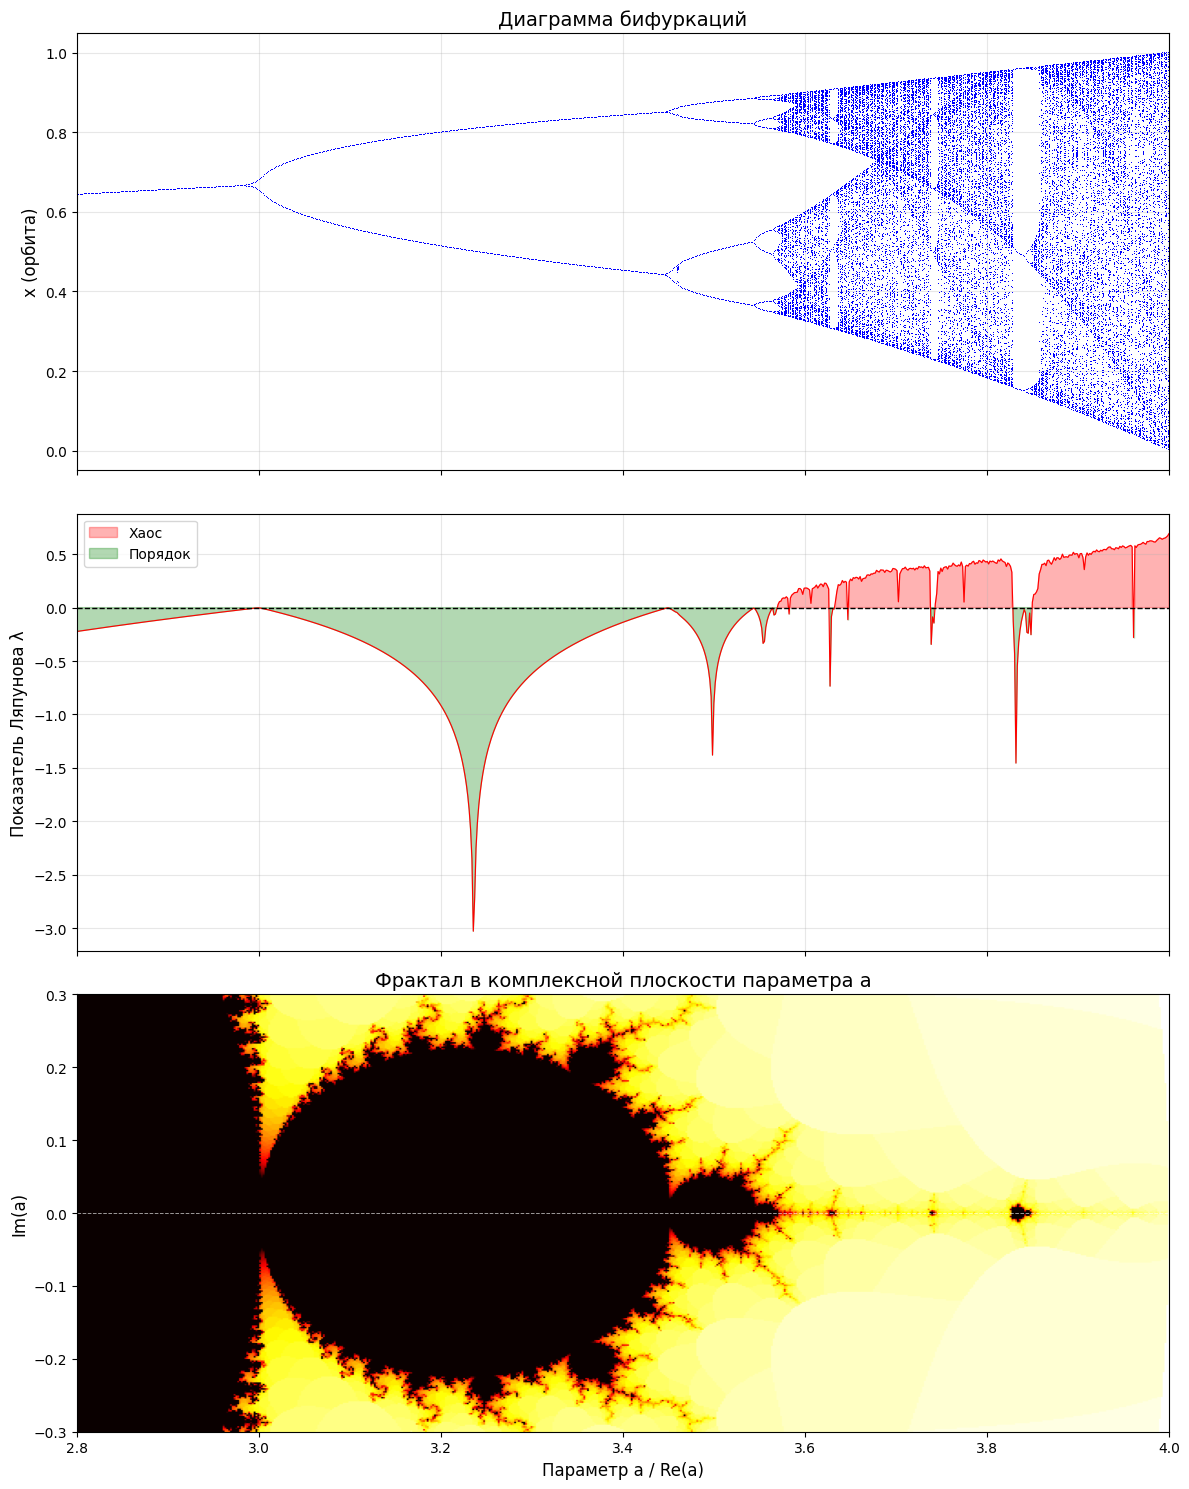

In [455]:
draw_combined_chart([2.8, 4.0], X0, process, n_points=800)

На этой комбинированной визуализации прекрасно видна связь между:
- **Структурой орбит** (верхний график)
- **Хаотичностью системы** (средний график)
- **Структурой фрактала в комплексной плоскости параметра a** (нижний график)

**Ключевые наблюдения:**

1. В точках бифуркаций показатель Ляпунова проходит через ноль
2. В окнах периодичности (где орбита имеет конечное число точек) λ < 0
3. В областях "густого заполнения" орбиты λ > 0 (хаос)
4. Чем больше λ, тем сильнее хаотичность

Показатель Ляпунова - это универсальный инструмент диагностики хаоса,
применимый к любым динамическим системам!

## Заключение

Мы прошли путь от простого итерационного процесса x → a·x·(1-x)
до глубоких концепций теории хаоса:

**1. Детерминированный хаос:**
   Простые детерминированные правила могут порождать непредсказуемое поведение

**2. Каскад бифуркаций:**
   Переход от порядка к хаосу происходит через последовательность удвоений периода

**3. Универсальность:**
   Константы Фейгенбаума появляются в любых системах с аналогичной динамикой

**4. Фрактальная структура:**
   Граница между порядком и хаосом имеет самоподобную структуру

**5. Чувствительность к начальным условиям:**
   Показатель Ляпунова количественно измеряет экспоненциальное расхождение траекторий

**6. Окна периодичности:**
   Даже в глубоком хаосе существуют "островки порядка"

Эти принципы применимы далеко за пределами математики: от популяционной динамики
до турбулентности, от экономических циклов до нейронных сетей, от погоды до
квантовой механики.

**Главный урок теории хаоса:** Мир не делится на "простой и предсказуемый" или
"случайный и беспорядочный". Существует третья категория - *детерминированный хаос* -
системы, подчиняющиеся строгим законам, но демонстрирующие непредсказуемое поведение.

Простое уравнение x_{n+1} = a·x_n·(1-x_n) содержит в себе бесконечную сложность.
Это одновременно и урок скромности (мы не можем предсказать даже простые системы),
и урок вдохновения (простота может содержать бесконечную красоту).